# Testing the model

In [1]:
# Set the base dir to the project root
%cd ..
!pwd

/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


In [2]:
import torch
import pandas as pd
import os
from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from main import parse_config, reduce_dimensionality, test_model, make_dataset
import numpy as np
import matplotlib.pyplot as plt


In [3]:
config = parse_config(config_path="output/pbip/best/training_config.yaml")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[INFO] Configuration loaded from output/pbip/best/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=0, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TopBottomTruncateStrategy(), overlap=0, model_name='nucleotide-transform

### Load dataset

In [4]:
# Hardcode test dataset path. Only used for the PredPHI data, on the CI4CB data, ignore this cell.
config.input_perphect.couples_df = "data/perphect-data/predphi/predphi_test_dataset.csv"

In [5]:
# Assumming that all the embeddings have already been computed
output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from data/embeddings-pbip


In [6]:
bacteria_df, phages_df, couples_df = PerphectDataInput(input_paths=config.input_perphect).load()


[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...


In [7]:
bacteria_model_names = [x.name() for x in config.bacteria_embedding_models]
phages_model_names = [x.name() for x in config.phages_embedding_models]
dataset = make_dataset(couples_df, bacteria_model_names, phages_model_names, output_manager, device)
dataset = reduce_dimensionality(dataset, config.training_config.reduce_dimensionality, config.output_dir, config.training_config.n_components_bacteria, config.training_config.n_components_phages)


[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 1236 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model DNABERT2-BottomTruncateStrategy-ov0-maxlen16384 from data/embeddings-pbip


...

[DEBUG] Loading 1236 embeddings for model MegaDNA-TopBottomTruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model DNABERT2-TKPert-concat-J16-g20-ov0-maxlen16384 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 2500
[DEBUG] Final embedding size (phages): 15752


In [8]:
dataset.head()

,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,NC_019400,CALF01000071,1,"[tensor(0.0652, device='cuda:0'), tensor(0.015...","[tensor(0.1758, device='cuda:0'), tensor(0.233..."
1,MF919516,CP012196,0,"[tensor(-0.0643, device='cuda:0'), tensor(-0.0...","[tensor(0.3073, device='cuda:0'), tensor(0.416..."
2,NC_019813,CP011132,0,"[tensor(0.0619, device='cuda:0'), tensor(0.162...","[tensor(0.0379, device='cuda:0'), tensor(0.155..."
3,NC_027355,CM000736,1,"[tensor(-0.0317, device='cuda:0'), tensor(-0.2...","[tensor(0.0881, device='cuda:0'), tensor(-0.12..."
4,NC_021790,CP009976,1,"[tensor(-0.1541, device='cuda:0'), tensor(-0.6...","[tensor(0.0610, device='cuda:0'), tensor(0.036..."


### Load the model
Make sure to use the same architecture and parameters that were used for training it. See the yaml file that was used.

In [9]:
model_path = os.path.join(config.output_dir, "trained_model.pth")

In [10]:
bacterium_embed_size = len(dataset["bacterium_embedding"].iloc[0])
phage_embed_size = len(dataset["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)

### Test the model

In [11]:
test_model(dataset, model, batch_size=config.training_config.batch_size, device=device);

[INFO] Starting testing...
[INFO] Accuracy (test): 0.7508090734481812
[INFO] Recall (test): 0.7750809192657471
[INFO] F1 score (test): 0.7567140460014343
[INFO] Loss (test): 0.7344119616310959
[INFO] Confusion Matrix (test) (TP, FP, FN, TN): (479, 169, 139, 449)


### Do 1 prediction

In [12]:
# Do 1 prediction example
example = dataset.iloc[0]
bacterium_embedding = example["bacterium_embedding"].clone().detach().unsqueeze(0).to(device)
phage_embedding = example["phage_embedding"].clone().detach().unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(bacterium_embedding, phage_embedding)
    probs = torch.sigmoid(output).squeeze().cpu().numpy()
    print(f"Predicted interaction probability for bacterium {example['bacterium_id']} and phage {example['phage_id']}: Label {np.argmax(probs)} with probability {np.max(probs):.6f}. True label: {example['interaction_type']}")

Predicted interaction probability for bacterium CALF01000071 and phage NC_019400: Label 0 with probability 0.750215. True label: 1


### View missed predictions

In [13]:
model.eval()
with torch.no_grad():
    preds, probs = [], []
    for _, row in dataset.iterrows():
        output = model(
            row['bacterium_embedding'].unsqueeze(0).to(device),
            row['phage_embedding'].unsqueeze(0).to(device),
        )
        p = torch.softmax(output, dim=1)[0]
        preds.append(int(p.argmax().item()))
        probs.append(float(p[1].item()))

dataset['prediction']  = preds
dataset['probability'] = probs
dataset.head()

,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding,prediction,probability
0,NC_019400,CALF01000071,1,"[tensor(0.0652, device='cuda:0'), tensor(0.015...","[tensor(0.1758, device='cuda:0'), tensor(0.233...",0,0.111976
1,MF919516,CP012196,0,"[tensor(-0.0643, device='cuda:0'), tensor(-0.0...","[tensor(0.3073, device='cuda:0'), tensor(0.416...",0,0.127122
2,NC_019813,CP011132,0,"[tensor(0.0619, device='cuda:0'), tensor(0.162...","[tensor(0.0379, device='cuda:0'), tensor(0.155...",0,0.156426
3,NC_027355,CM000736,1,"[tensor(-0.0317, device='cuda:0'), tensor(-0.2...","[tensor(0.0881, device='cuda:0'), tensor(-0.12...",0,0.079894
4,NC_021790,CP009976,1,"[tensor(-0.1541, device='cuda:0'), tensor(-0.6...","[tensor(0.0610, device='cuda:0'), tensor(0.036...",1,0.972886


In [14]:
print(dataset.groupby('interaction_type')['probability'].describe())


                  count      mean       std           min       25%       50%  \
interaction_type                                                                
0                 618.0  0.272351  0.376301  1.833486e-17  0.000063  0.023252   
1                 618.0  0.731262  0.325284  4.273067e-06  0.566396  0.904630   

                       75%       max  
interaction_type                      
0                 0.577270  0.999563  
1                 0.981504  0.999902  


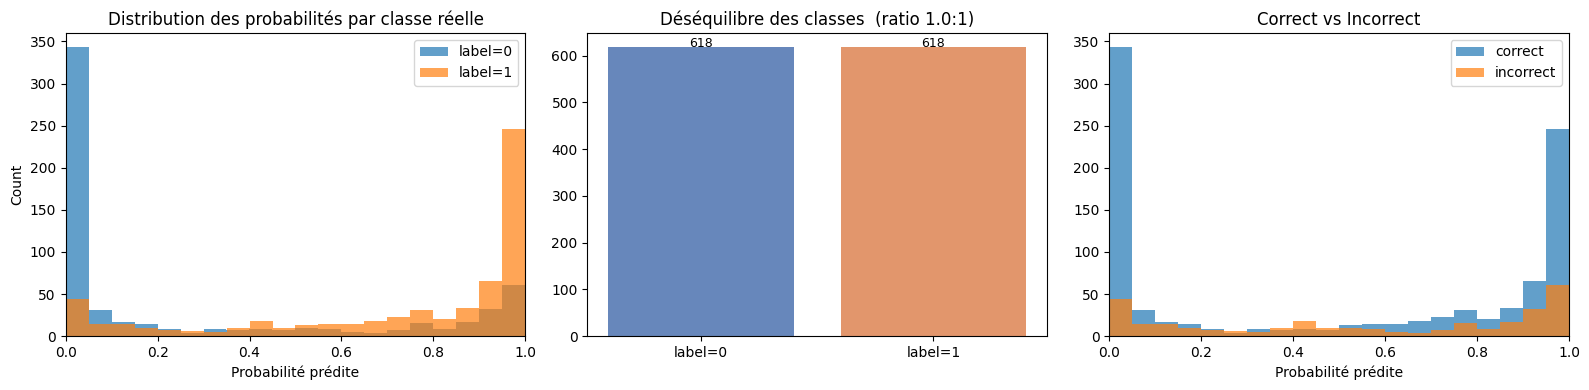

In [15]:
# ── Distribution globale des sorties ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, grp in dataset.groupby('interaction_type'):
    axes[0].hist(grp['probability'], bins=20, alpha=0.7, label=f'label={int(label)}')
axes[0].set_xlabel('Probabilité prédite'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution des probabilités par classe réelle'); axes[0].legend()
axes[0].set_xlim(0, 1)

counts = dataset['interaction_type'].value_counts().sort_index()
axes[1].bar([f'label={int(i)}' for i in counts.index], counts.values,
            color=['#4C72B0', '#DD8452'], alpha=0.85)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)
axes[1].set_title(f'Déséquilibre des classes  (ratio {counts.max()/counts.min():.1f}:1)')

correct = dataset['prediction'] == dataset['interaction_type']
axes[2].hist(dataset[correct]['probability'],  bins=20, alpha=0.7, label='correct')
axes[2].hist(dataset[~correct]['probability'], bins=20, alpha=0.7, label='incorrect')
axes[2].set_xlabel('Probabilité prédite'); axes[2].set_title('Correct vs Incorrect'); axes[2].legend()
axes[2].set_xlim(0, 1)
plt.tight_layout(); plt.show()


In [16]:
def entity_summary(dataset, id_col):
    rows = []
    for entity_id, grp in dataset.groupby(id_col):
        n_pos   = int((grp['interaction_type'] == 1).sum())
        n_neg   = int((grp['interaction_type'] == 0).sum())
        n_total = n_pos + n_neg
        mse     = ((grp['probability'] - grp['interaction_type']) ** 2).mean()
        bias    = (grp['probability'] - grp['interaction_type']).mean()
        acc     = (grp['prediction'] == grp['interaction_type']).mean()
        mean_pred = grp['probability'].mean()
        rows.append({
            id_col:      entity_id,
            'n_pos':     n_pos,
            'n_neg':     n_neg,
            'n_total':   n_total,
            'ratio_pos': n_pos / n_total,
            'mean_pred': mean_pred,
            'mse':       mse,
            'bias':      bias,
            'accuracy':  acc,
        })
    return pd.DataFrame(rows).set_index(id_col).sort_values('mse', ascending=False)

bact_summary  = entity_summary(dataset, 'bacterium_id')
phage_summary = entity_summary(dataset, 'phage_id')

print('=== Bactéries (triées par MSE, n_total >= 10) ===')
print(bact_summary[bact_summary['n_total'] >= 10].to_string(float_format='{:.3f}'.format))
print()
print('=== Phages (triés par MSE, n_total >= 4) ===')
print(phage_summary[phage_summary['n_total'] >= 4].to_string(float_format='{:.3f}'.format))


=== Bactéries (triées par MSE, n_total >= 10) ===
              n_pos  n_neg  n_total  ratio_pos  mean_pred   mse   bias  accuracy
bacterium_id                                                                    
HG530068         97      4      101      0.960      0.492 0.456 -0.468     0.475
CP000628          2      9       11      0.182      0.682 0.433  0.500     0.455
CP000113          1      9       10      0.100      0.499 0.365  0.399     0.600
CP005976          4      7       11      0.364      0.199 0.332 -0.165     0.636
CP000554         21      2       23      0.913      0.540 0.314 -0.373     0.565
CP010812         26      2       28      0.929      0.477 0.303 -0.452     0.571
CP001932          1     10       11      0.091      0.314 0.299  0.224     0.545
CP009257         22      5       27      0.815      0.596 0.296 -0.219     0.556
CP014326          1      9       10      0.100      0.425 0.287  0.325     0.600
CP001312          4      7       11      0.364      0.614 0

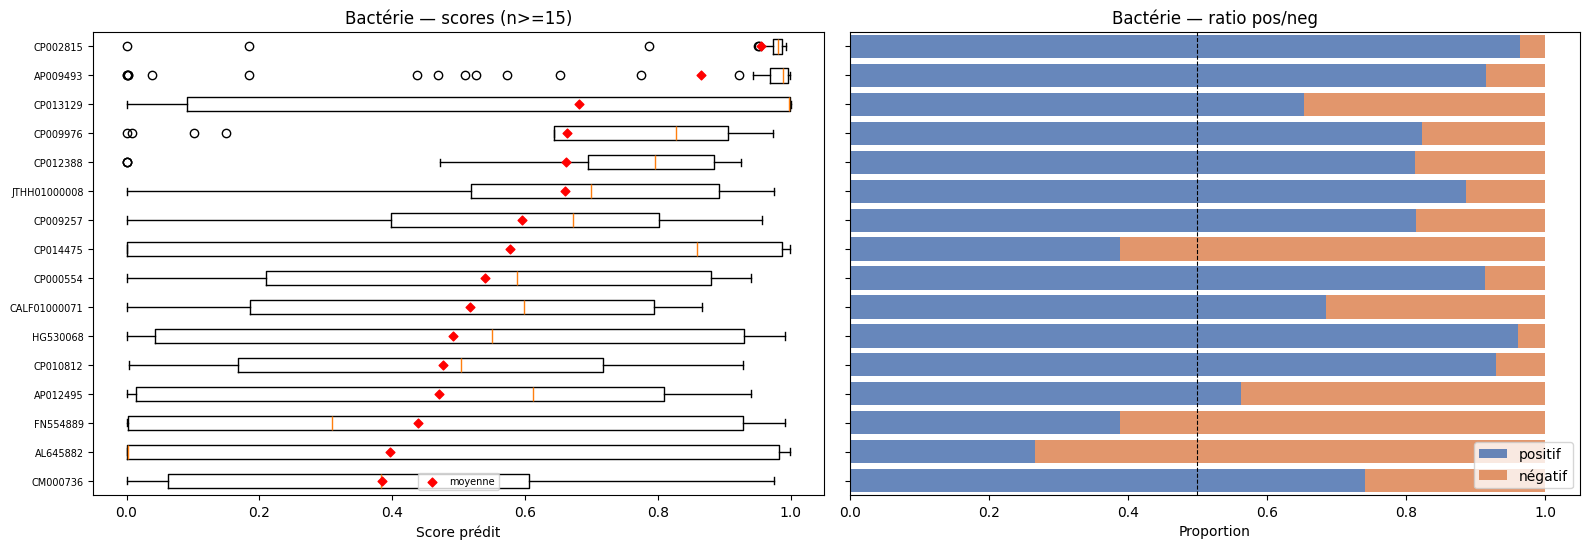

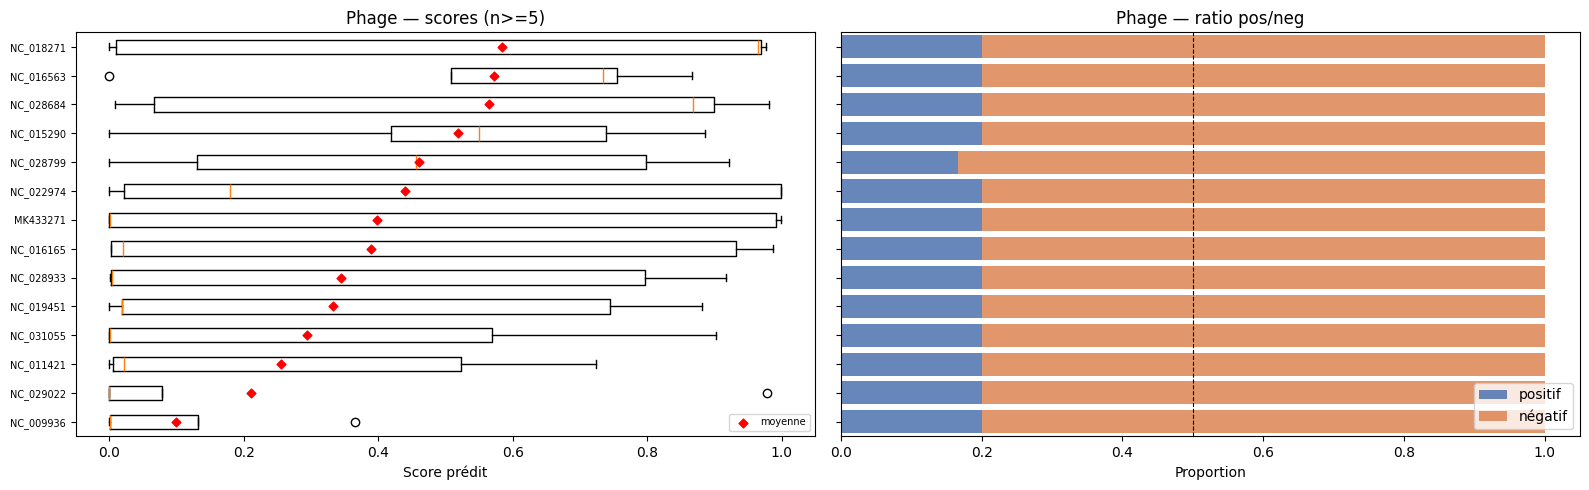

In [17]:
def plot_entity_distribution(summary, dataset, id_col, min_total, title):
    sub = summary[summary['n_total'] >= min_total].sort_values('mean_pred')
    order = sub.index

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(order) * 0.35)), sharey=True)

    # Boxplot horizontal + moyenne (depuis dataset brut)
    data  = [dataset[dataset[id_col] == e]['probability'].values for e in order]
    means = sub['mean_pred'].values
    axes[0].boxplot(data, positions=range(len(order)), vert=False)
    axes[0].scatter(means, range(len(order)), marker='D', color='red',
                    zorder=3, s=20, label='moyenne')
    axes[0].set_xlabel('Score prédit'); axes[0].set_title(f'{title} — scores (n>={min_total})')
    axes[0].tick_params(axis='y', labelsize=7); axes[0].legend(fontsize=7)

    # Stacked bar ratio pos/neg (depuis summary)
    y = range(len(order))
    axes[1].barh(y, sub['ratio_pos'],                 alpha=0.85, color='#4C72B0', label='positif')
    axes[1].barh(y, 1 - sub['ratio_pos'], left=sub['ratio_pos'], alpha=0.85, color='#DD8452', label='négatif')
    axes[1].set_yticks(y); axes[1].set_yticklabels(order, fontsize=7)
    axes[1].set_xlabel('Proportion'); axes[1].set_title(f'{title} — ratio pos/neg')
    axes[1].legend(loc='lower right')
    axes[1].axvline(0.5, color='black', linewidth=0.8, linestyle='--')

    plt.tight_layout(); plt.show()

plot_entity_distribution(bact_summary,  dataset, 'bacterium_id', 15, 'Bactérie')
plot_entity_distribution(phage_summary, dataset, 'phage_id',      5, 'Phage')


In [18]:
cp_samples = dataset[dataset['bacterium_id'] == 'CP013129']
print(cp_samples[['phage_id', 'interaction_type','prediction', 'probability']].to_string())


       phage_id  interaction_type  prediction   probability
21    NC_018849                 0           0  6.139980e-03
22    NC_005345                 1           1  9.991038e-01
34     KT184391                 1           1  9.984484e-01
141    KT895281                 0           0  2.463874e-04
277    KT186228                 1           1  9.986824e-01
279   NC_028827                 1           1  9.984301e-01
350   NC_018848                 1           1  9.999019e-01
358    MK305888                 1           1  9.984698e-01
386    MF541406                 1           1  9.856354e-01
410    KY092482                 1           1  9.996865e-01
541    KX507344                 1           1  9.915355e-01
646    KU958700                 1           1  9.988426e-01
660    KT124228                 1           1  9.909400e-01
716   NC_023566                 0           0  1.656398e-06
773   NC_001396                 0           0  1.987025e-04
785    KT186229                 1       

In [19]:
from enum import Enum
from pbi_models.embedders import AbstractModel
from pbi_utils.embeddings_merging_strategies import TopBottomTruncateStrategy


class Side(Enum):
    bact = 'bactérie'
    phage = 'phage'

    @property
    def embedding_col(self):
        return 'bacterium_embedding' if self is Side.bact else 'phage_embedding'

    def choose(self, bact, phage):
        return bact if self is Side.bact else phage

    def get_df(self):
        """Retourne bacteria_df ou phages_df (globales du notebook)."""
        return self.choose(bacteria_df, phages_df)


class ModelInfo:
    """Informations sur un modèle d'embedding et ses scores XAI."""

    def __init__(self, model: AbstractModel, slice: slice, side: Side):
        self.model = model
        self.slice = slice
        self.side = side
        self.result: dict = {}

    @property
    def embedding_size(self) -> int:
        return self.slice.stop - self.slice.start

    @property
    def embedding_col(self) -> str:
        return self.side.embedding_col

    def get_model_slice(self, data):
        return data[self.slice]

    def slice_sides(self, bact_arr, phage_arr):
        return self.get_model_slice(self.side.choose(bact_arr, phage_arr))

    def name(self) -> str:
        vals = self.model.name().split('-')
        return f"{vals[0]} ({self.side.name})"

    def __repr__(self):
        return f"ModelInfo({self.name()}, slice={self.slice})"


class TopBottomModelInfo:
    """Demi-modèle (top ou bottom) d'un TopBottomTruncateStrategy."""

    class Part(Enum):
        top = 'top'
        bottom = 'bottom'

        def choose(self, top, bottom):
            return top if self is TopBottomModelInfo.Part.top else bottom

    def __init__(self, parent: 'ModelInfo', part: 'TopBottomModelInfo.Part'):
        self.parent = parent
        self.part = part

        start  = parent.slice.start
        middle = start + parent.embedding_size // 2
        stop   = parent.slice.stop
        self.slice = part.choose(slice(start, middle), slice(middle, stop))

        self.result: dict = {}

    @classmethod
    def from_parent(cls, parent: 'ModelInfo'):
        if not isinstance(parent.model.merging_strategy, TopBottomTruncateStrategy):
            raise ValueError(f"{parent.model.name()} n'utilise pas TopBottomTruncateStrategy")
        return cls(parent, cls.Part.top), cls(parent, cls.Part.bottom)

    @property
    def embedding_size(self) -> int:
        return self.slice.stop - self.slice.start

    @property
    def side(self) -> Side:
        return self.parent.side

    @property
    def model(self) -> AbstractModel:
        return self.parent.model

    @property
    def embedding_col(self) -> str:
        return self.side.embedding_col

    def get_model_slice(self, data):
        return data[self.slice]

    def slice_sides(self, bact_arr, phage_arr):
        return self.get_model_slice(self.side.choose(bact_arr, phage_arr))

    def name(self) -> str:
        return f"{self.parent.name()} ({self.part.name} splitted)"

    def __repr__(self):
        return f"TopBottomModelInfo({self.name()}, slice={self.slice})"


# ── Plot utility functions ────────────────────────────────────────────────────
def plot_importance_bars(info_dicts_configs, mean_bact, mean_phage, suptitle):
    fig, axes = plt.subplots(1, len(info_dicts_configs), figsize=(18, 5))
    fig.subplots_adjust(bottom=0.25)
    for ax, (info_dict, attr, side_label, color, ylabel) in zip(axes, info_dicts_configs):
        labels = [info.name() for info in info_dict.values()]
        vals   = [getattr(info.slice_sides(mean_bact, mean_phage), attr)() for info in info_dict.values()]
        bars   = ax.bar(range(len(vals)), vals, color=color, alpha=0.85)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_title(f'{side_label} — {attr}')
        ax.set_ylabel(ylabel)
        for bar, val, info in zip(bars, vals, info_dict.values()):
            ax.text(bar.get_x() + bar.get_width() / 2, val * 0.5,
                    f'{info.embedding_size}d',
                    ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    plt.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_per_dimension_importance(bact_info, phage_info, mean_bact, mean_phage, suptitle, ylabel,
                                  bact_color='#4C72B0', phage_color='#DD8452'):
    fig, axes = plt.subplots(2, len(bact_info), figsize=(16, 8))
    for col, info in enumerate(bact_info.values()):
        axes[0][col].plot(info.get_model_slice(mean_bact), linewidth=0.6, alpha=0.8, color=bact_color)
        axes[0][col].set_title('Bactérie — ' + info.name(), fontsize=8)
        axes[0][col].set_xlabel('Dimension')
        axes[0][col].set_ylabel(ylabel)
    for col, info in enumerate(phage_info.values()):
        axes[1][col].plot(info.get_model_slice(mean_phage), linewidth=0.6, alpha=0.8, color=phage_color)
        axes[1][col].set_title('Phage — ' + info.name(), fontsize=8)
        axes[1][col].set_xlabel('Dimension')
        axes[1][col].set_ylabel(ylabel)
    plt.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_heatmap_matrix(ax, matrix, xlabels, ylabels, title,
                         cmap='RdYlGn_r', fmt='{:+.3f}',
                         vmin=None, vmax=None, fontsize=9):
    kwargs = dict(cmap=cmap, aspect='auto')
    if vmin is not None: kwargs['vmin'] = vmin
    if vmax is not None: kwargs['vmax'] = vmax
    im = ax.imshow(matrix, **kwargs)
    ax.set_xticks(range(len(xlabels))); ax.set_xticklabels(xlabels, rotation=30, ha='right')
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(len(ylabels)):
        for j in range(len(xlabels)):
            ax.text(j, i, fmt.format(matrix[i, j]), ha='center', va='center',
                    fontsize=fontsize, fontweight='bold')


### Gradient-based embedding importance

Pour chaque sample, on calcule le gradient de la sortie du modèle par rapport aux embeddings d'entrée.  
Un gradient élevé sur une dimension = le modèle y est très sensible = elle influence fortement la prédiction.

In [20]:
# Construction des ModelInfo pour chaque modèle d'embedding.
def build_model_info(models, sample_id, side: Side) -> dict:
    info, start = {}, 0
    for m in models:
        emb = output_manager.load_embedding_batch([sample_id], model_name=m.name(),
                                                   silent=True, device=device)
        size = len(emb[0])
        info[m.name()] = ModelInfo(m, slice(start, start + size), side)
        start += size
    return info


sample_bact_id  = dataset['bacterium_id'].iloc[0]
sample_phage_id = dataset['phage_id'].iloc[0]

bact_info  = build_model_info(config.bacteria_embedding_models, sample_bact_id,  Side.bact)
phage_info = build_model_info(config.phages_embedding_models,   sample_phage_id, Side.phage)
base_infos = [bact_info, phage_info]

for info_dict in base_infos:
    side = next(iter(info_dict.values())).side
    print(f'{side.name}:')
    for info in info_dict.values():
        print(f'  {info.name()}: {info.embedding_size} dims')
    print(f'  Total: {sum(v.embedding_size for v in info_dict.values())}')


[DEBUG] Loading 1 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model DNABERT2-BottomTruncateStrategy-ov0-maxlen16384 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model NT2-TopBottomTruncateStrategy-250M-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model MegaDNA-TopBottomTruncateStrategy-concat-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model DNABERT2-TKPert-concat-J16-g20-ov0-maxlen16384 from data/embeddings-pbip
bact:
  NT2 (bact): 768 dims
  MegaDNA (bact): 964 dims
  DNABERT2 (bact): 768 dims
  Total: 2500
phage:
  NT2 (phage): 1536 dims
  MegaDNA (phage): 1928 dims
  DNABERT2 (phage): 12288 dims
  Total: 15752


In [21]:
# Sous-infos top / bottom pour les modèles TopBottomTruncateStrategy, par side
topbottom_bact_info:  dict = {}
topbottom_phage_info: dict = {}
for info_dict in base_infos:
    for name, info in info_dict.items():
        if not isinstance(info.model.merging_strategy, TopBottomTruncateStrategy):
            continue
        top, bot = TopBottomModelInfo.from_parent(info)
        target = topbottom_bact_info if info.side is Side.bact else topbottom_phage_info
        target[name + '_top']    = top
        target[name + '_bottom'] = bot

# Copies de bact_info/phage_info sans les parents TopBottom (déjà représentés par topbottom_*_info)
def _without_tb_parents(info_dict):
    return {k: v for k, v in info_dict.items()
            if not isinstance(v.model.merging_strategy, TopBottomTruncateStrategy)}

bact_info_solo  = _without_tb_parents(bact_info)
phage_info_solo = _without_tb_parents(phage_info)

bact_extended  = {**bact_info_solo,  **topbottom_bact_info}
phage_extended = {**phage_info_solo, **topbottom_phage_info}

extended_infos = [bact_extended, phage_extended]

for info in list(topbottom_bact_info.values()) + list(topbottom_phage_info.values()):
    print(f'  {info.name()}: {info.embedding_size} dims ({info.part.name})')


  NT2 (phage) (top splitted): 768 dims (top)
  NT2 (phage) (bottom splitted): 768 dims (bottom)
  MegaDNA (phage) (top splitted): 964 dims (top)
  MegaDNA (phage) (bottom splitted): 964 dims (bottom)


In [22]:
# Étape 2 : calculer les gradients pour chaque sample
# On backpropage depuis la probabilité de la CLASSE 1 (interaction = vrai)
# car le modèle retourne 2 logits → shape (1, 2) → on prend output[:, 1]
model.eval()

all_grad_bact = []
all_grad_phage = []

for _, row in dataset.iterrows():
    bact_emb = row["bacterium_embedding"].clone().float().to(device).unsqueeze(0).requires_grad_(True)
    phage_emb = row["phage_embedding"].clone().float().to(device).unsqueeze(0).requires_grad_(True)

    output = model(bact_emb, phage_emb)          # shape (1, 2)
    prob = torch.sigmoid(output[:, 1]).squeeze()  # probabilité classe 1, scalaire
    prob.backward()

    all_grad_bact.append(bact_emb.grad.squeeze().abs().detach().cpu().numpy())
    all_grad_phage.append(phage_emb.grad.squeeze().abs().detach().cpu().numpy())

mean_grad_bact = np.mean(all_grad_bact, axis=0)
mean_grad_phage = np.mean(all_grad_phage, axis=0)

print(f"Gradients calculés sur {len(all_grad_bact)} samples.")


Gradients calculés sur 1236 samples.


In [23]:
print('Importance par modèle (sum |gradient|):')
for side_label, info_dict in [('Bactérie', bact_info), ('Phage', phage_info)]:
    print(f'{side_label}:')
    for info in info_dict.values():
        g = info.slice_sides(mean_grad_bact, mean_grad_phage)
        print(f'  {info.name()}: sum={g.sum():.4f}  mean={g.mean():.6f}  dims={len(g)}')


Importance par modèle (sum |gradient|):
Bactérie:
  NT2 (bact): sum=4.0825  mean=0.005316  dims=768
  MegaDNA (bact): sum=4.8301  mean=0.005010  dims=964
  DNABERT2 (bact): sum=3.5130  mean=0.004574  dims=768
Phage:
  NT2 (phage): sum=8.9175  mean=0.005806  dims=1536
  MegaDNA (phage): sum=9.7183  mean=0.005041  dims=1928
  DNABERT2 (phage): sum=38.3948  mean=0.003125  dims=12288


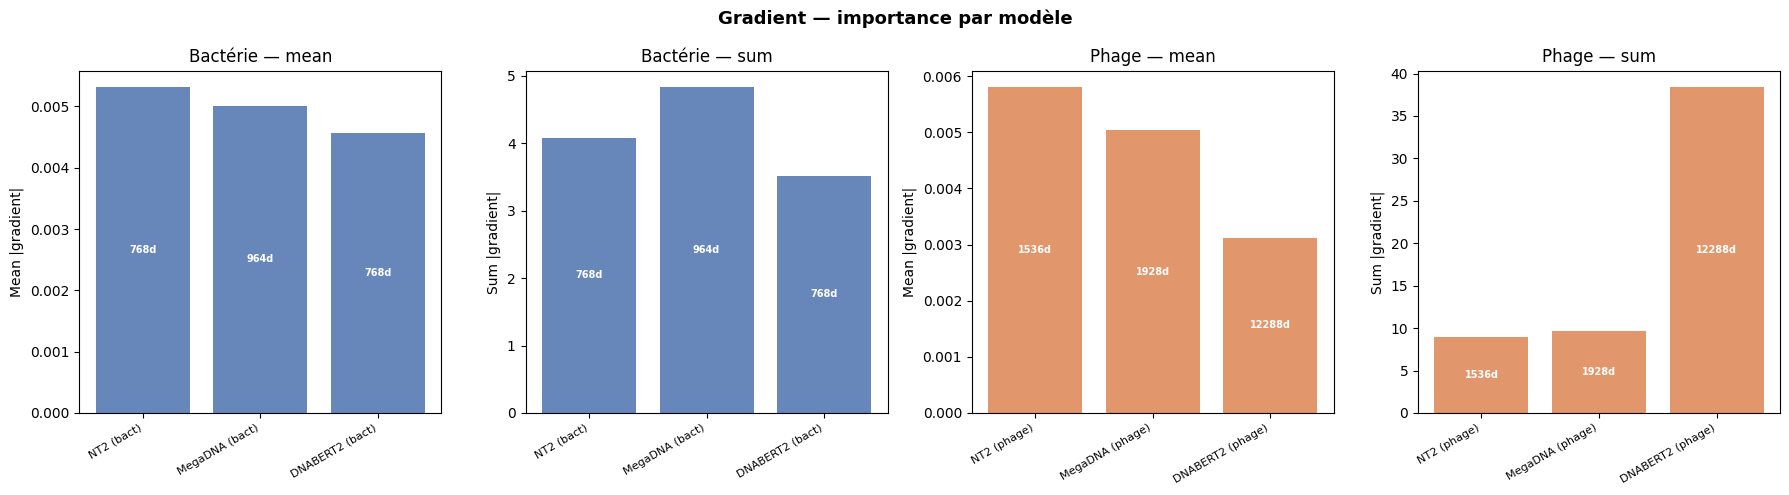

In [24]:
plot_importance_bars(
    [
        (bact_info,  'mean', 'Bactérie', '#4C72B0', 'Mean |gradient|'),
        (bact_info,  'sum',  'Bactérie', '#4C72B0', 'Sum |gradient|'),
        (phage_info, 'mean', 'Phage',    '#DD8452', 'Mean |gradient|'),
        (phage_info, 'sum',  'Phage',    '#DD8452', 'Sum |gradient|'),
    ],
    mean_grad_bact, mean_grad_phage,
    suptitle='Gradient — importance par modèle',
)


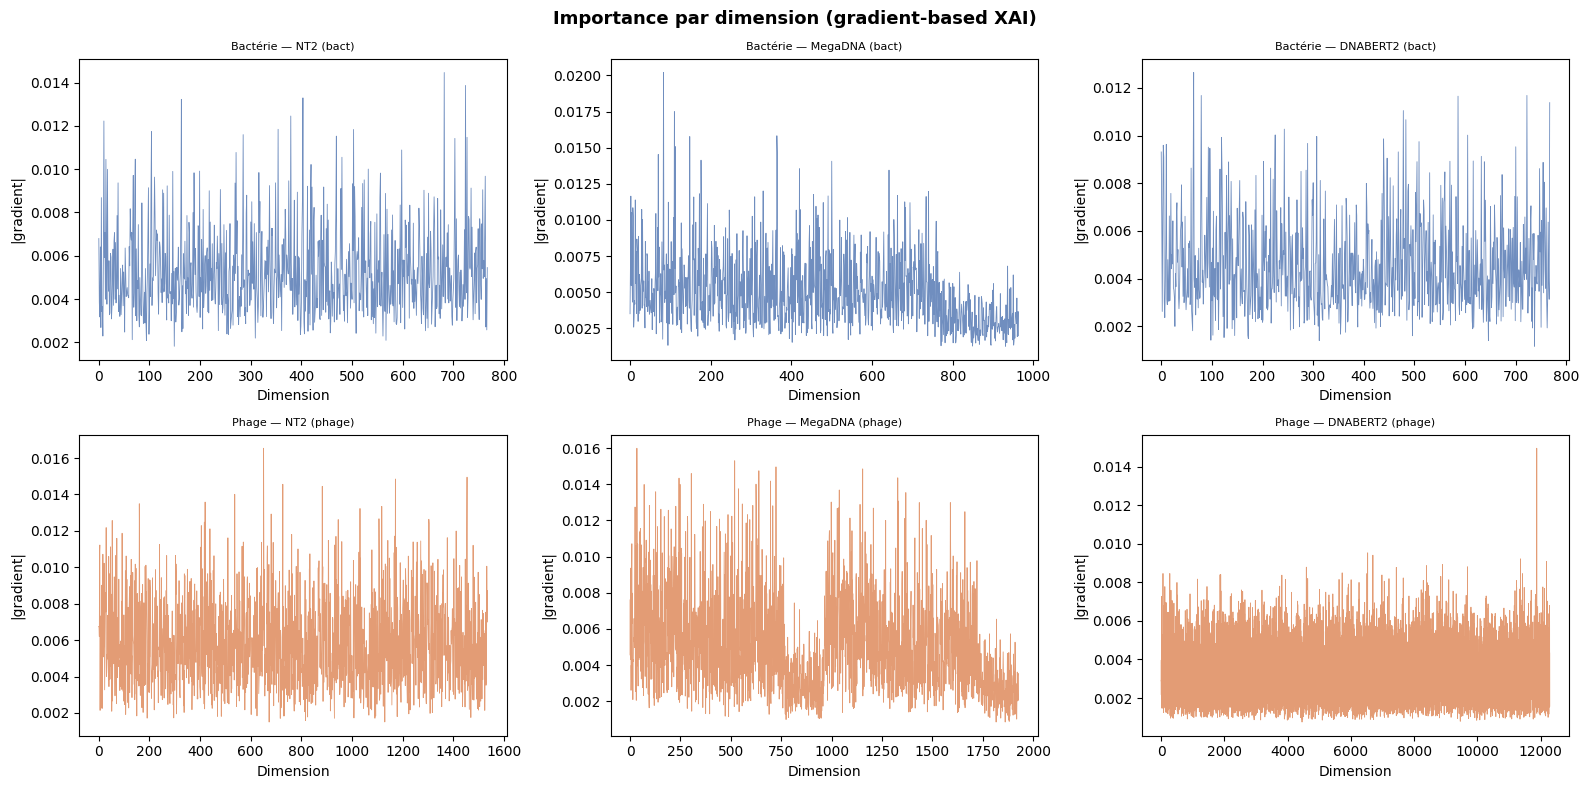

In [25]:
plot_per_dimension_importance(
    bact_info, phage_info,
    mean_grad_bact, mean_grad_phage,
    suptitle='Importance par dimension (gradient-based XAI)',
    ylabel='|gradient|',
)


### Integrated Gradients (IG)

Contrairement au gradient simple (calculé au point x), IG intègre les gradients sur tout le chemin depuis une **baseline** (embedding nul) jusqu'à x :

```
IG(x) = (x - 0) * mean(gradients sur 50 interpolations de 0 → x)
```

Propriété **completeness** : `sum(IG_bact) + sum(IG_phage) ≈ prob(x) - prob(baseline)` — vérifiable et garanti.

In [ ]:
from captum.attr import IntegratedGradients, NoiseTunnel


all_bact_embs  = torch.stack([t.detach().cpu() for t in dataset['bacterium_embedding']])
all_phage_embs = torch.stack([t.detach().cpu() for t in dataset['phage_embedding']])

median_bact  = torch.median(all_bact_embs,  dim=0).values.float().to(device)
median_phage = torch.median(all_phage_embs, dim=0).values.float().to(device)

del all_phage_embs
del all_bact_embs


def forward_prob(bact_emb, phage_emb):
    """Retourne la proba de classe 1 (sigmoid), shape [B, 1]. Conserve completeness sur les probas."""
    return torch.sigmoid(model(bact_emb, phage_emb)[:, 1:2])


ig = IntegratedGradients(forward_prob)


# Vérification completeness sur 1 sample avec baseline = médiane
model.eval()
row0 = dataset.iloc[0]
b0 = row0['bacterium_embedding'].to(device).unsqueeze(0)
p0 = row0['phage_embedding'].to(device).unsqueeze(0)

attr_b0, attr_p0 = ig.attribute(
    inputs=(b0, p0),
    baselines=(median_bact.unsqueeze(0), median_phage.unsqueeze(0)),
    target=0, n_steps=50,
)

with torch.no_grad():
    prob_x        = forward_prob(b0, p0).item()
    prob_baseline = forward_prob(median_bact.unsqueeze(0), median_phage.unsqueeze(0)).item()

ig_sum = attr_b0.sum().item() + attr_p0.sum().item()
delta  = prob_x - prob_baseline
print(f'Sum(IG)            : {ig_sum:.4f}')
print(f'prob(x)-prob(base) : {delta:.4f}')
print(f'Erreur completeness: {abs(ig_sum - delta):.6f}  (doit etre proche de 0)')


Sum(IG)            : -0.4479
prob(x)-prob(base) : -0.4544
Erreur completeness: 0.006539  (doit etre proche de 0)


In [44]:
# Calcul des IG sur tout le dataset via captum
N_STEPS = 50


def compute_mean_ig(baseline_bact, baseline_phage, n_steps=N_STEPS):
    all_b, all_p = [], []
    model.eval()
    for _, row in dataset.iterrows():
        b = row['bacterium_embedding'].clone().float().to(device).unsqueeze(0)
        p = row['phage_embedding'].clone().float().to(device).unsqueeze(0)
        attr_b, attr_p = ig.attribute(
            inputs=(b, p),
            baselines=(baseline_bact, baseline_phage),
            target=0, n_steps=n_steps,
        )
        all_b.append(attr_b.squeeze().abs().cpu().numpy())
        all_p.append(attr_p.squeeze().abs().cpu().numpy())
    return np.mean(all_b, axis=0), np.mean(all_p, axis=0)


# Baseline = médiane
mean_ig_bact, mean_ig_phage = compute_mean_ig(
    median_bact.unsqueeze(0), median_phage.unsqueeze(0),
)

# Baseline = zéro
mean_ig_bact_zero, mean_ig_phage_zero = compute_mean_ig(
    torch.zeros_like(median_bact).unsqueeze(0),
    torch.zeros_like(median_phage).unsqueeze(0),
)


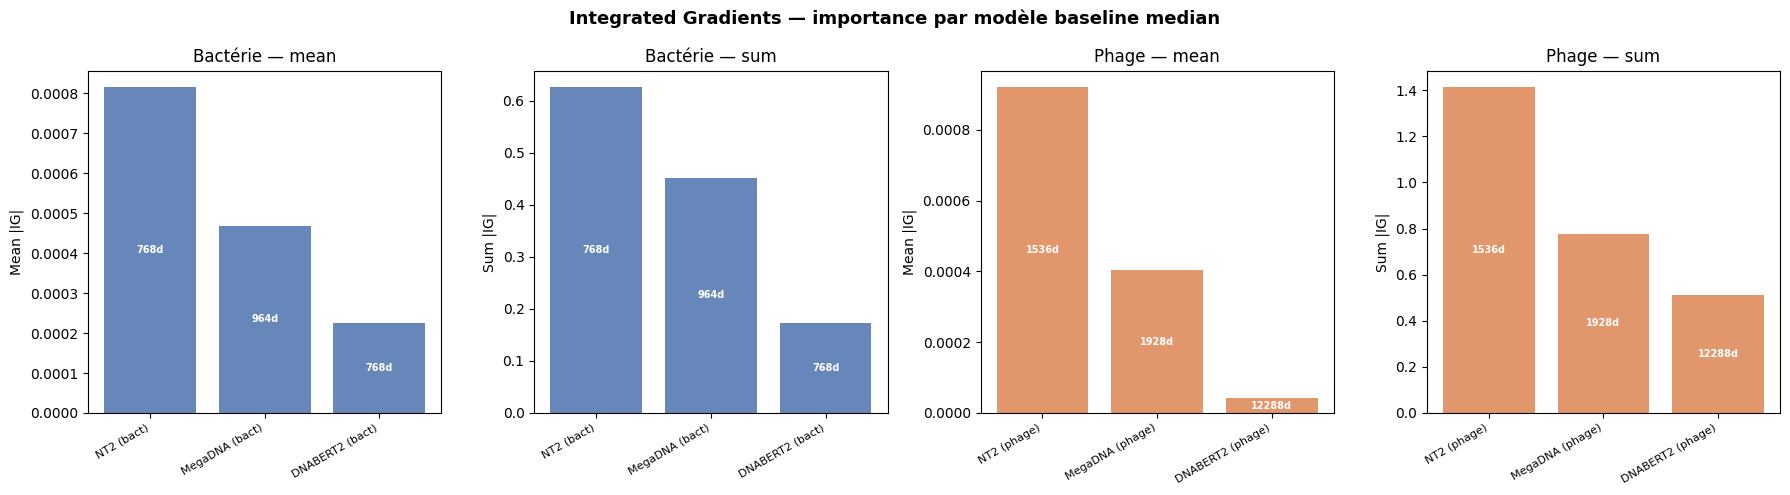

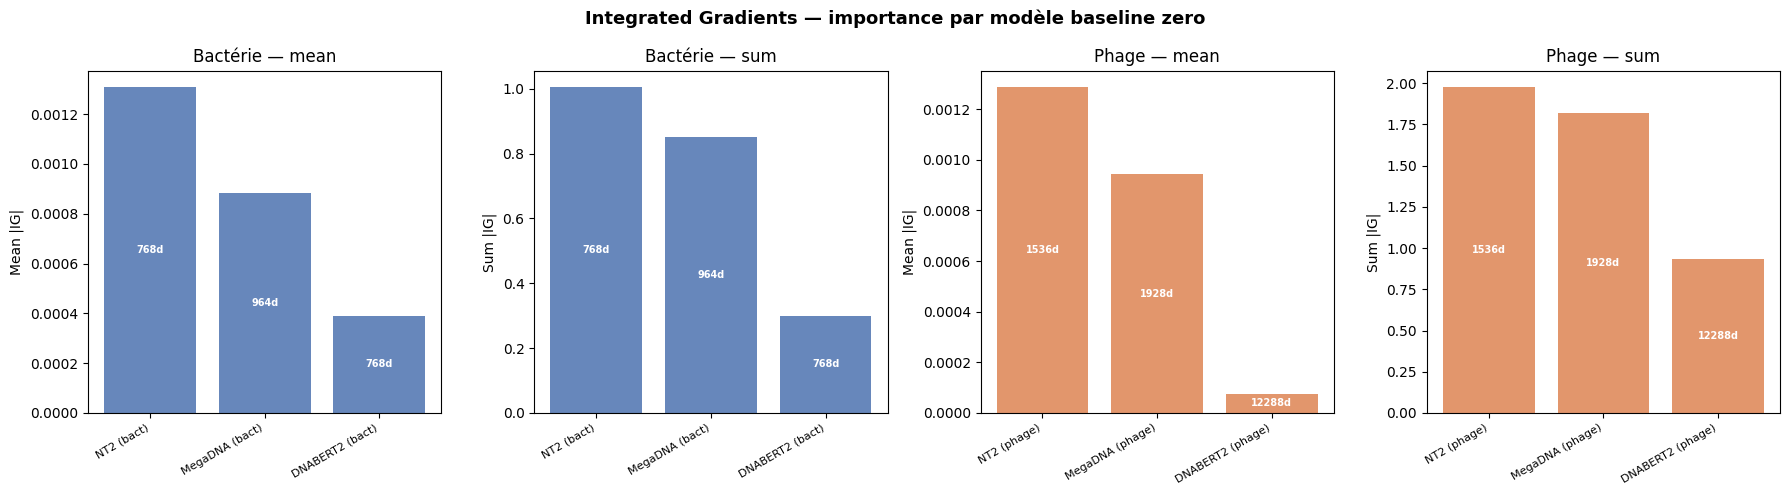

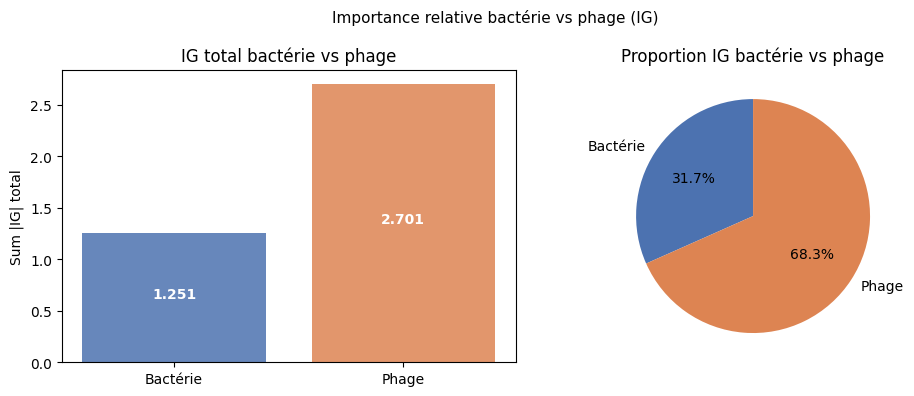

Bactérie : 1.251 (31.7%)
Phage    : 2.701 (68.3%)
ratio importance 2.1594462394714355 phages


In [45]:
plot_importance_bars(
    [
        (bact_info,  'mean', 'Bactérie', '#4C72B0', 'Mean |IG|'),
        (bact_info,  'sum',  'Bactérie', '#4C72B0', 'Sum |IG|'),
        (phage_info, 'mean', 'Phage',    '#DD8452', 'Mean |IG|'),
        (phage_info, 'sum',  'Phage',    '#DD8452', 'Sum |IG|'),
    ],
    mean_ig_bact, mean_ig_phage,
    suptitle='Integrated Gradients — importance par modèle baseline median',
)

plot_importance_bars(
    [
        (bact_info,  'mean', 'Bactérie', '#4C72B0', 'Mean |IG|'),
        (bact_info,  'sum',  'Bactérie', '#4C72B0', 'Sum |IG|'),
        (phage_info, 'mean', 'Phage',    '#DD8452', 'Mean |IG|'),
        (phage_info, 'sum',  'Phage',    '#DD8452', 'Sum |IG|'),
    ],
    mean_ig_bact_zero, mean_ig_phage_zero,
    suptitle='Integrated Gradients — importance par modèle baseline zero',
)

# ── Bactérie vs Phage : somme totale des IG ──────────────────────────────────
total_bact  = mean_ig_bact.sum()
total_phage = mean_ig_phage.sum()
total       = total_bact + total_phage

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Bactérie', 'Phage'], [total_bact, total_phage],
            color=['#4C72B0', '#DD8452'], alpha=0.85)
axes[0].set_ylabel('Sum |IG| total')
axes[0].set_title('IG total bactérie vs phage')
for i, v in enumerate([total_bact, total_phage]):
    axes[0].text(i, v * 0.5, f'{v:.3f}', ha='center', fontsize=10, color='white', fontweight='bold')
axes[1].pie([total_bact, total_phage], labels=['Bactérie', 'Phage'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion IG bactérie vs phage')
plt.suptitle('Importance relative bactérie vs phage (IG)', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Bactérie : {total_bact:.3f} ({100*total_bact/total:.1f}%)')
print(f'Phage    : {total_phage:.3f} ({100*total_phage/total:.1f}%)')
print(f'ratio importance {total_phage/total_bact} phages')

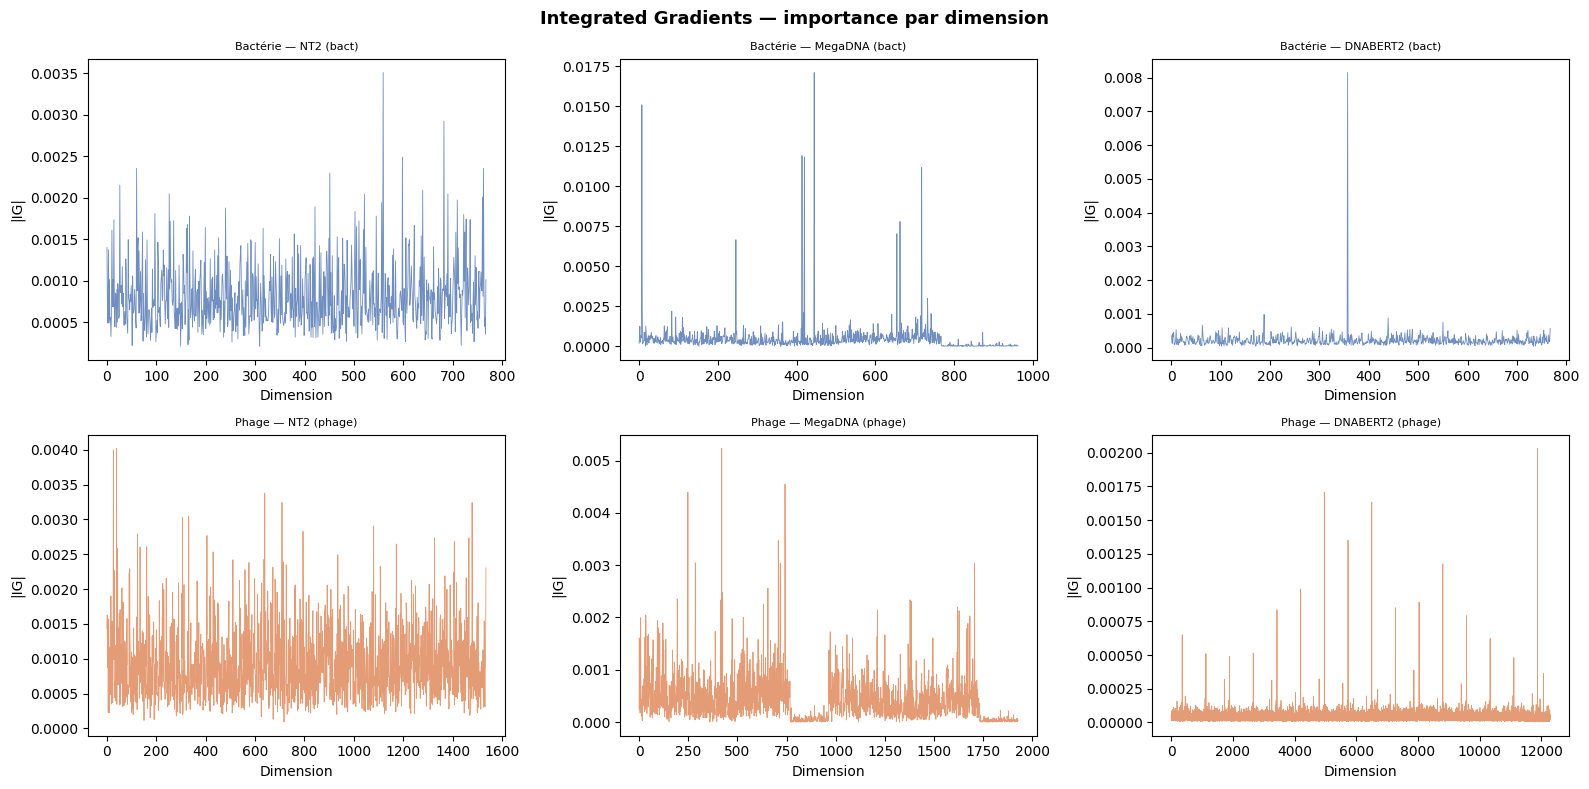

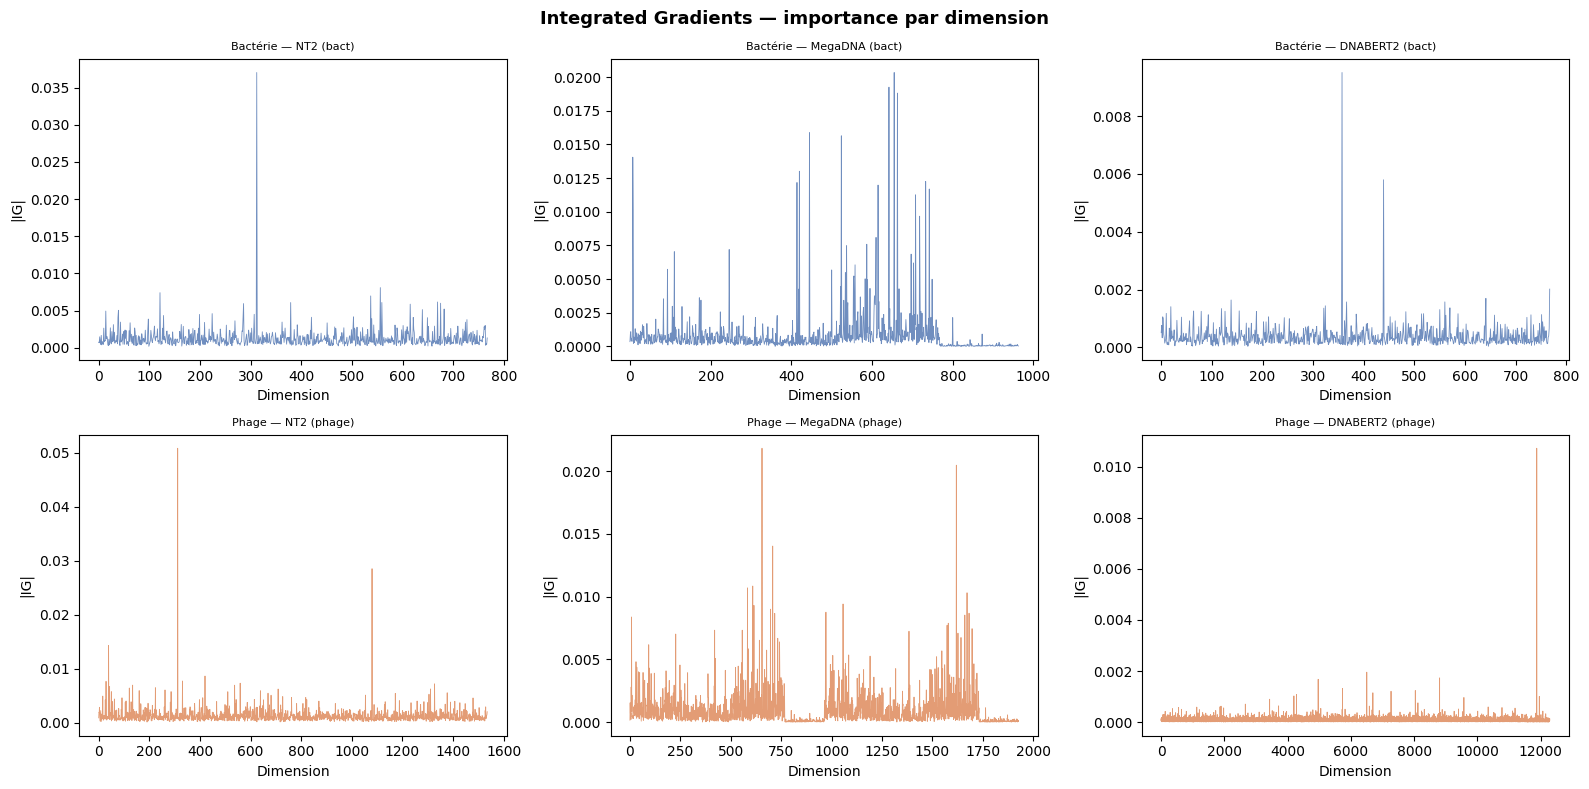

In [46]:
plot_per_dimension_importance(
    bact_info, phage_info,
    mean_ig_bact, mean_ig_phage,
    suptitle='Integrated Gradients — importance par dimension',
    ylabel='|IG|',
)

plot_per_dimension_importance(
    bact_info, phage_info,
    mean_ig_bact_zero, mean_ig_phage_zero,
    suptitle='Integrated Gradients — importance par dimension',
    ylabel='|IG|',
)


### Ablation study — mise à zéro d'un modèle

On remplace les dimensions d'un modèle (NT2, MegaDNA, DNABERT2) par des zéros dans **tous les samples**,
puis on mesure la chute de MSE par rapport au modèle complet.

Si IG et gradient prédisent correctement l'importance, les modèles avec le plus grand sum d'importance
devraient causer la plus grande chute de MSE quand on les supprime.

In [59]:
import random


def swap_embeddings(dataset:pd.DataFrame, infos:list[ModelInfo]):
    """Remplace chaque slice par celui d'un donneur aléatoire. Un seul run."""
    ds = dataset.copy()
    n  = len(ds)
    others = [random.randint(0, n - 1) for _ in range(n)]
    for info in infos:
        col, sl = info.embedding_col, info.slice
        new = []
        for i, e in enumerate(ds[col]):
            e = e.clone()
            e[sl] = dataset[col][others[i]][sl]
            new.append(e)
        ds[col] = new
    return ds


def zero_embeddings(dataset:pd.DataFrame, infos:list[ModelInfo], value=0.0):
    """Remplit la slice avec une constante scalaire (0.0 par défaut)."""
    ds = dataset.copy()
    for info in infos:
        col, sl = info.embedding_col, info.slice
        new = []
        for e in ds[col]:
            e = e.clone()
            e[sl] = value
            new.append(e)
        ds[col] = new
    return ds

def median_embeddings(dataset:pd.DataFrame, infos:list[ModelInfo]):
    """Remplit la slice avec une constante scalaire (0.0 par défaut)."""
    ds = dataset.copy()
    for info in infos:
        col, sl = info.embedding_col, info.slice
        new = []
        for e in ds[col]:
            e = e.clone()
            e[sl] = info.side.choose(median_bact, median_phage)[sl]
            new.append(e)
        ds[col] = new
    return ds


def get_mcc(ds):
    cm, _ = test_model(ds, model, batch_size=config.training_config.batch_size, device=device, silent=True)
    tn, fp, fn, tp = cm.ravel()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) ** 0.5
    return (tp*tn - fp*fn) / denom if denom > 0 else 0.0



def run_zero_embeddings(dataset:pd.DataFrame, infos:list[ModelInfo], list = [0.0]):
    return np.mean([get_mcc(zero_embeddings(dataset, infos, float(i))) for i in list])

def run_swap_embeddings(dataset:pd.DataFrame, infos:list[ModelInfo]):
    return np.mean([get_mcc(swap_embeddings(dataset, infos)) for i in range(5)])

def run_median_embeddings(dataset, infos):
    return get_mcc(median_embeddings(dataset, infos))


def get_metrics(ds_orig, ds_perturbed):
    """Calcule dprob, dmse et dmcc en une passe. Cher à appeler le moins possible."""
    model.eval()
    delta_probs, delta_mses = [], []
    with torch.no_grad():
        for (_, ro), (_, rz) in zip(ds_orig.iterrows(), ds_perturbed.iterrows()):
            prob_o = float(ro['probability'])
            prob_z = torch.sigmoid(model(
                rz['bacterium_embedding'].float().to(device).unsqueeze(0),
                rz['phage_embedding'].float().to(device).unsqueeze(0)
            )[:, 1]).item()
            label  = float(ro['interaction_type'])
            delta_probs.append(abs(prob_o - prob_z))
            delta_mses.append((prob_o - label)**2 - (prob_z - label)**2)
    return np.mean(delta_probs), np.mean(delta_mses), get_mcc(ds_perturbed) - get_mcc(ds_orig)


In [83]:
baseline_mcc = get_mcc(dataset)
print(f'MCC baseline: {baseline_mcc:.4f}')

for info_dict in [bact_info, phage_info, topbottom_bact_info, topbottom_phage_info]:
    for name, info in info_dict.items():
        dp, dm, dmcc = get_metrics(dataset, zero_embeddings(dataset, [info]))
        dpS, dmS, dmccS = get_metrics(dataset, median_embeddings(dataset, [info]))        
        info.result['ablation'] = {
            'zero': {'dprob': dp,  'dmse': dm,  'dmcc': dmcc},
            'median': {'dprob': dpS, 'dmse': dmS, 'dmcc': dmccS},
        }
        print(f"{info.name()} zero   — ΔMCC: {dmcc:+.4f}  ΔMSE: {dm:+.4f}")
        print(f"{info.name()} median — ΔMCC: {dmccS:+.4f}  ΔMSE: {dmS:+.4f}\n")        


MCC baseline: 0.5022
NT2 (bact) zero — ΔMCC: -0.0428  ΔMSE: +0.0071
NT2 (bact) swap — ΔMCC: +0.0350  ΔMSE: +0.0276

MegaDNA (bact) zero — ΔMCC: -0.2821  ΔMSE: -0.0863
MegaDNA (bact) swap — ΔMCC: -0.2240  ΔMSE: -0.0464

DNABERT2 (bact) zero — ΔMCC: +0.0091  ΔMSE: +0.0243
DNABERT2 (bact) swap — ΔMCC: +0.0120  ΔMSE: +0.0250

NT2 (phage) zero — ΔMCC: -0.6407  ΔMSE: -0.2253
NT2 (phage) swap — ΔMCC: -0.2093  ΔMSE: -0.0403

MegaDNA (phage) zero — ΔMCC: -0.5792  ΔMSE: -0.1973
MegaDNA (phage) swap — ΔMCC: -0.0466  ΔMSE: +0.0032

DNABERT2 (phage) zero — ΔMCC: -0.0133  ΔMSE: +0.0207
DNABERT2 (phage) swap — ΔMCC: -0.0079  ΔMSE: +0.0170

NT2 (phage) (top splitted) zero — ΔMCC: -0.5022  ΔMSE: -0.1495
NT2 (phage) (top splitted) swap — ΔMCC: -0.1637  ΔMSE: -0.0286

NT2 (phage) (bottom splitted) zero — ΔMCC: -0.0198  ΔMSE: +0.0125
NT2 (phage) (bottom splitted) swap — ΔMCC: +0.0193  ΔMSE: +0.0284

MegaDNA (phage) (top splitted) zero — ΔMCC: -0.4414  ΔMSE: -0.1361
MegaDNA (phage) (top splitted) swap — ΔM

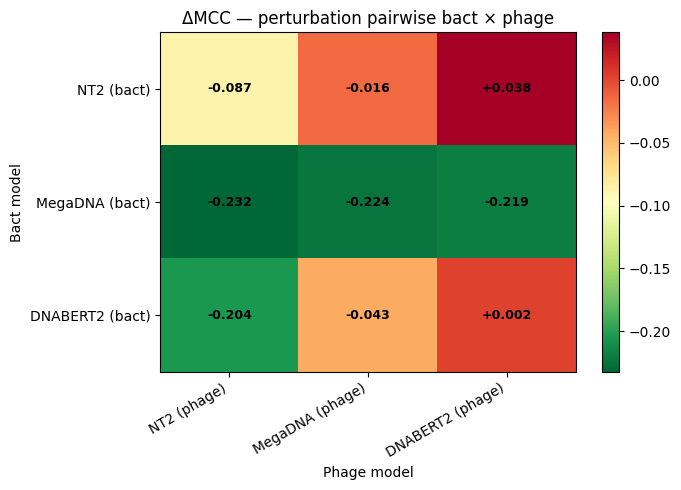

In [87]:
matrix_dmcc = np.zeros((len(bact_info), len(phage_info)))
for i, b_info in enumerate(bact_info.values()):
    for j, p_info in enumerate(phage_info.values()):
        mccs = [run_median_embeddings(dataset, [b_info, p_info])]
        matrix_dmcc[i, j] = np.mean(mccs) - baseline_mcc

xlabels = [info.name() for info in phage_info.values()]
ylabels = [info.name() for info in bact_info.values()]

fig, ax = plt.subplots(figsize=(7, 5))
plot_heatmap_matrix(ax, matrix_dmcc, xlabels, ylabels,
                    'ΔMCC — perturbation pairwise bact × phage')
ax.set_xlabel('Phage model'); ax.set_ylabel('Bact model')
plt.tight_layout(); plt.show()


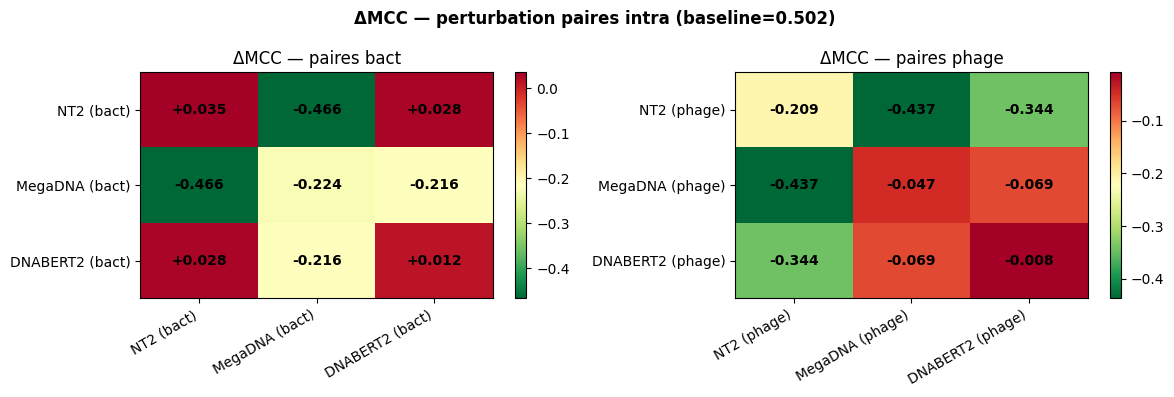

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, info_dict in zip(axes, base_infos):
    infos  = list(info_dict.values())
    n      = len(infos)
    matrix = np.full((n, n), np.nan)
    for i in range(n):
        for j in range(i, n):
            to_perturb = [infos[i]] if i == j else [infos[i], infos[j]]
            results    = [run_median_embeddings(dataset, to_perturb)]
            matrix[i, j] = matrix[j, i] = np.mean(results) - baseline_mcc
    labels = [info.name() for info in infos]
    side_name = infos[0].side.name
    plot_heatmap_matrix(ax, matrix, labels, labels, f'ΔMCC — paires {side_name}',
                        vmin=float(matrix.min()), vmax=float(matrix.max()), fontsize=10)
plt.suptitle(f'ΔMCC — perturbation paires intra (baseline={baseline_mcc:.3f})',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


Modèles entiers: 6 joueurs -> 64 coalitions (exact)
Extended (avec Top/Bottom): 8 joueurs -> 256 coalitions (exact)


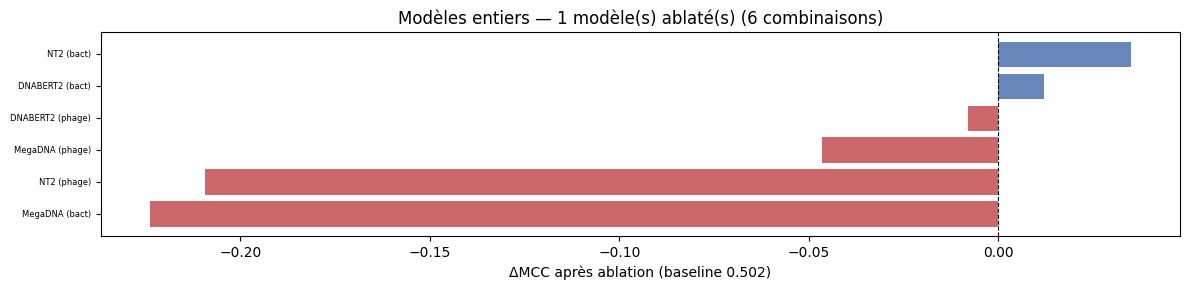

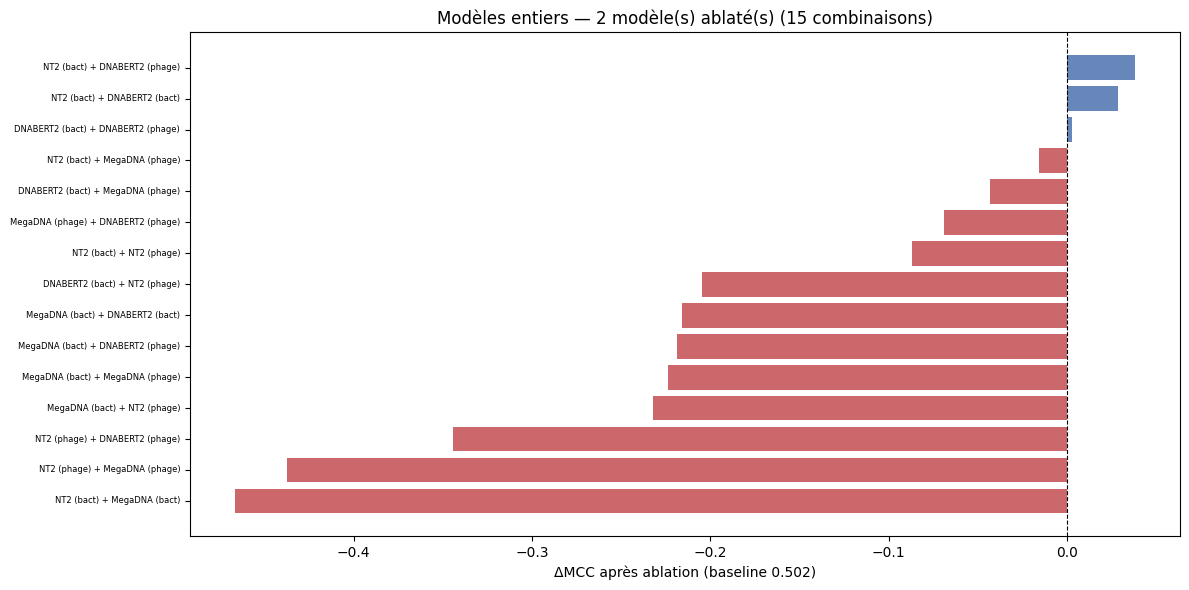

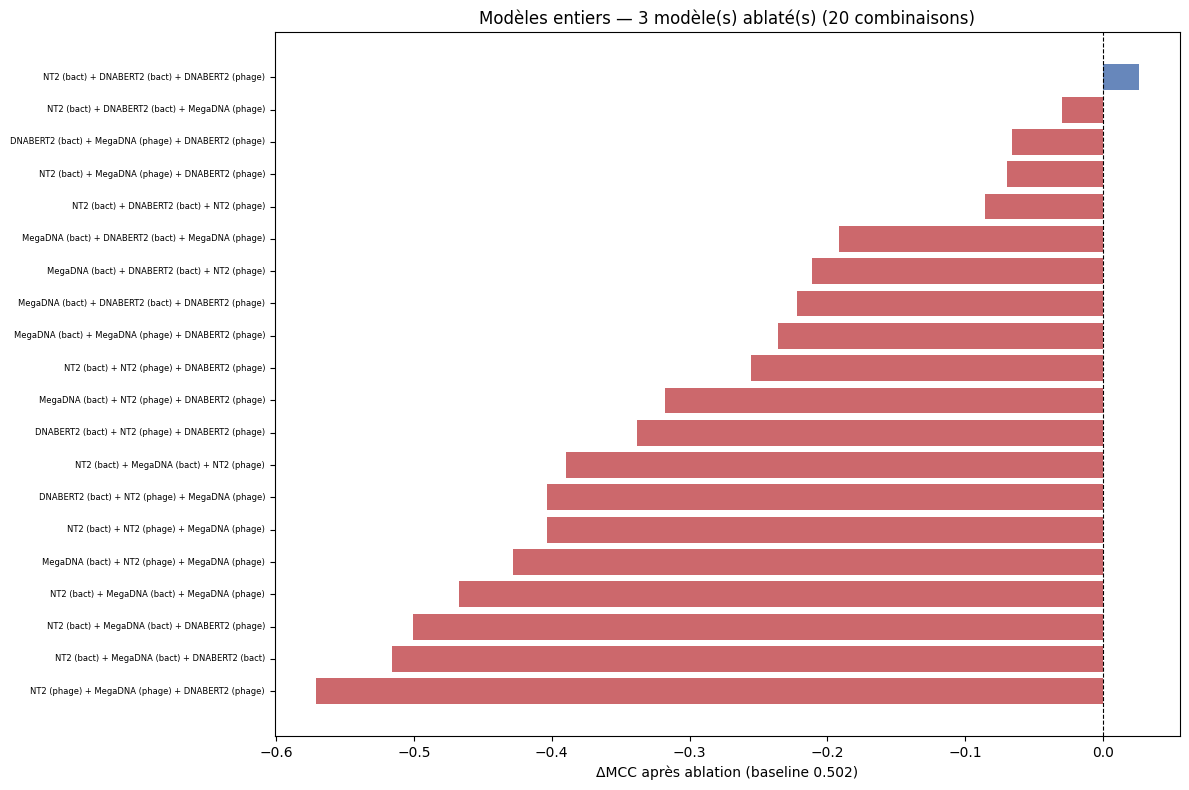

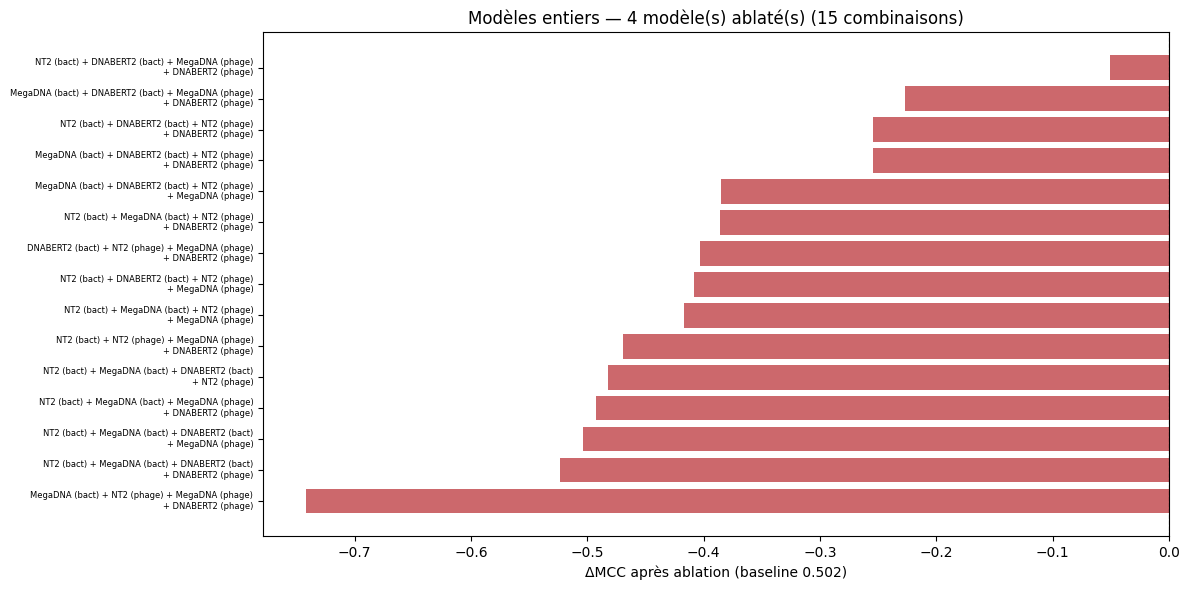

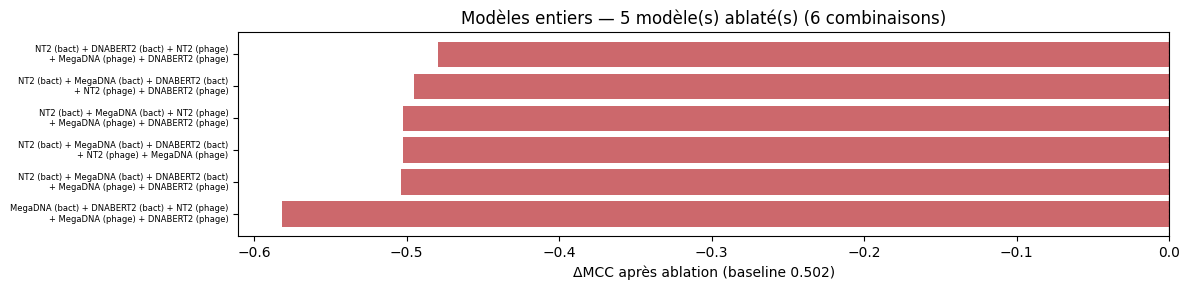

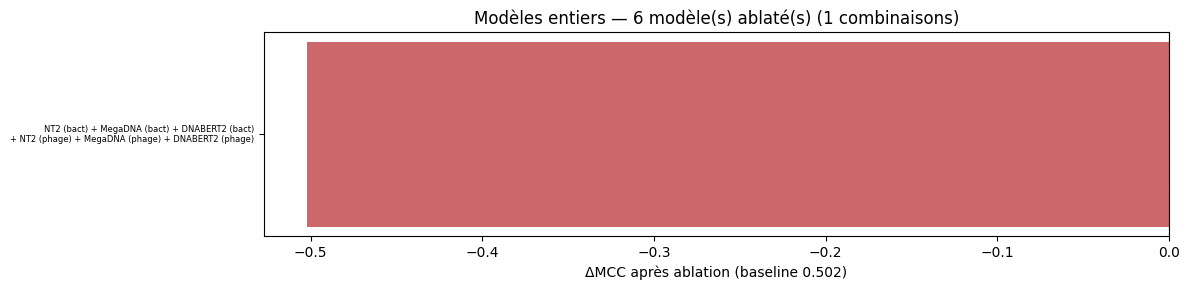

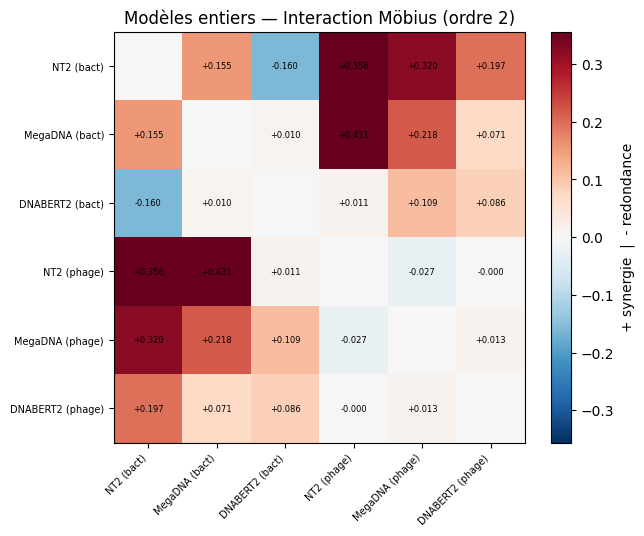

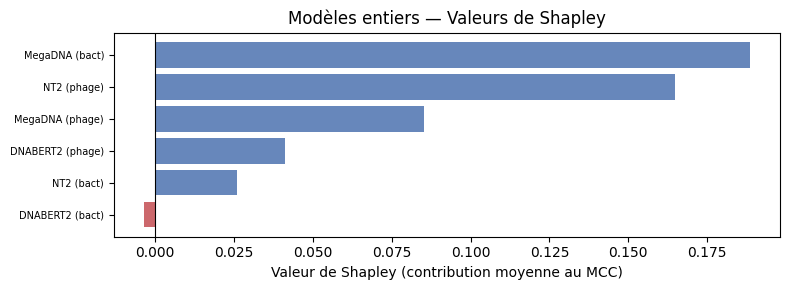

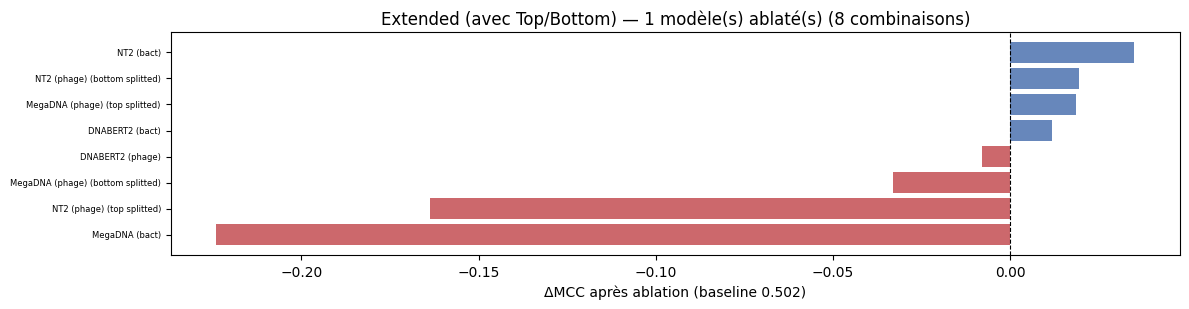

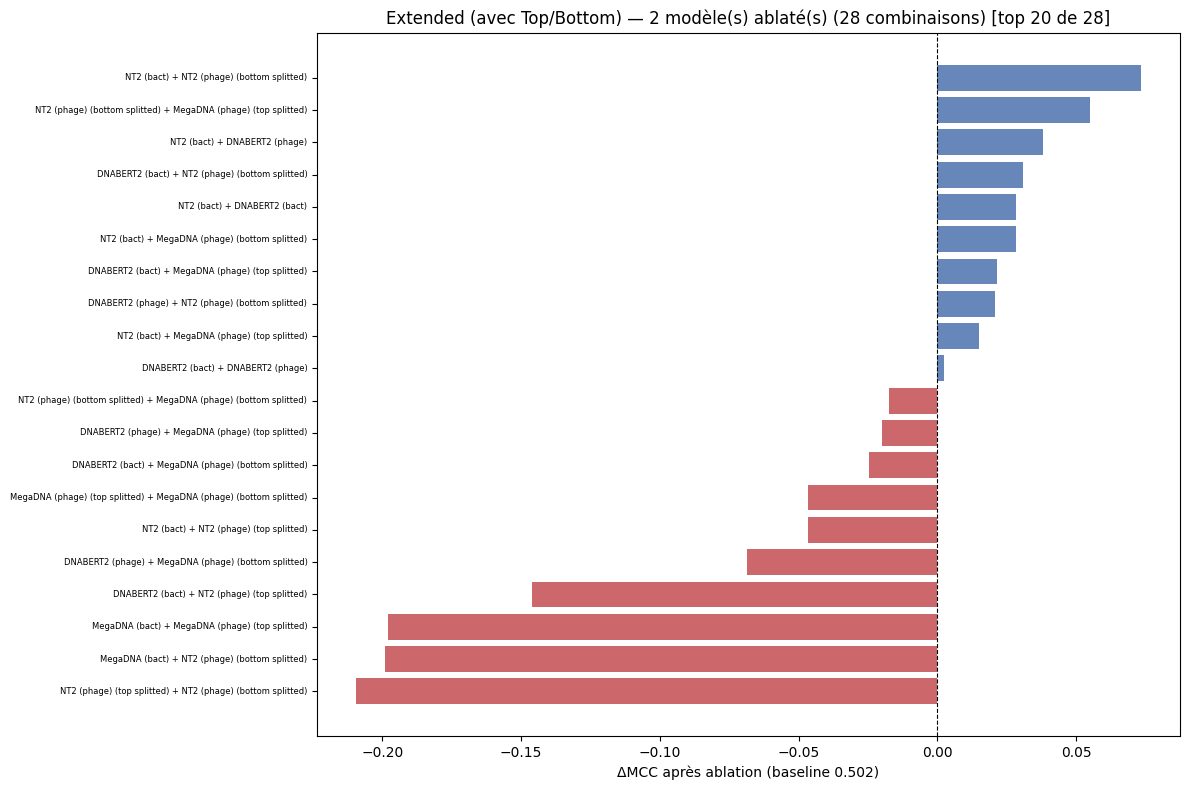

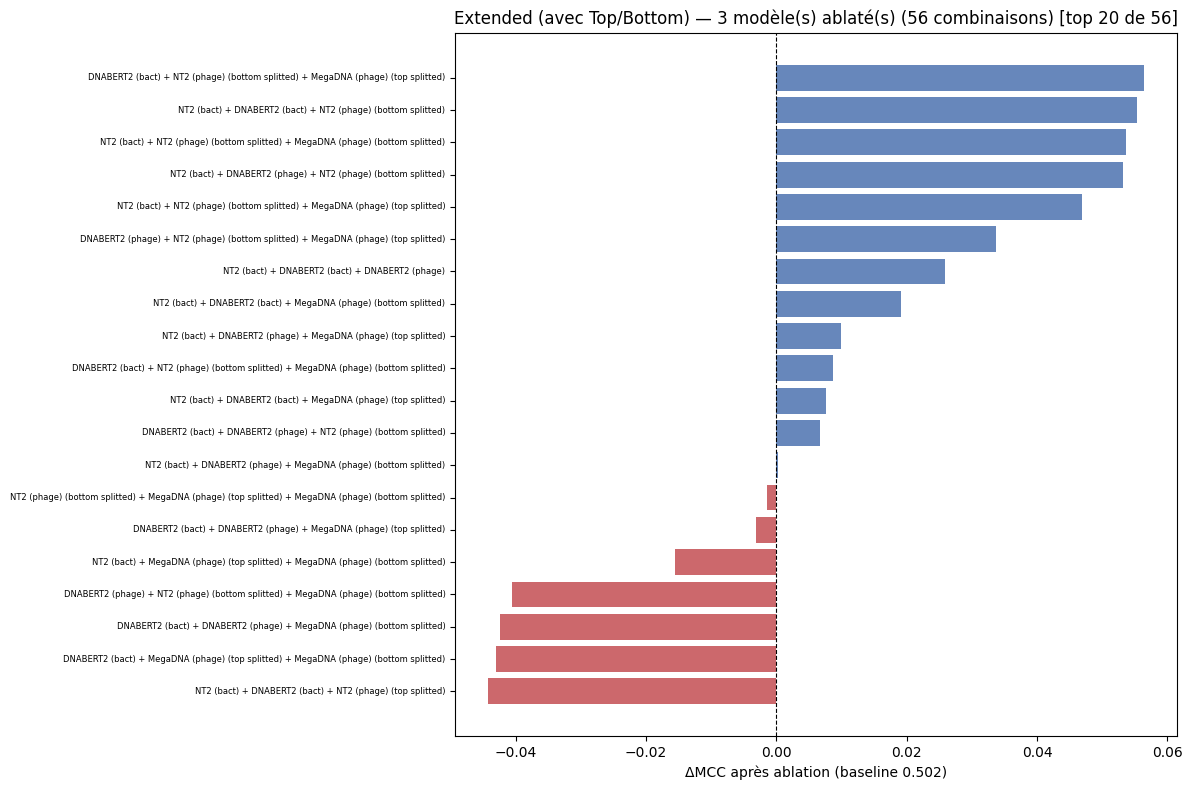

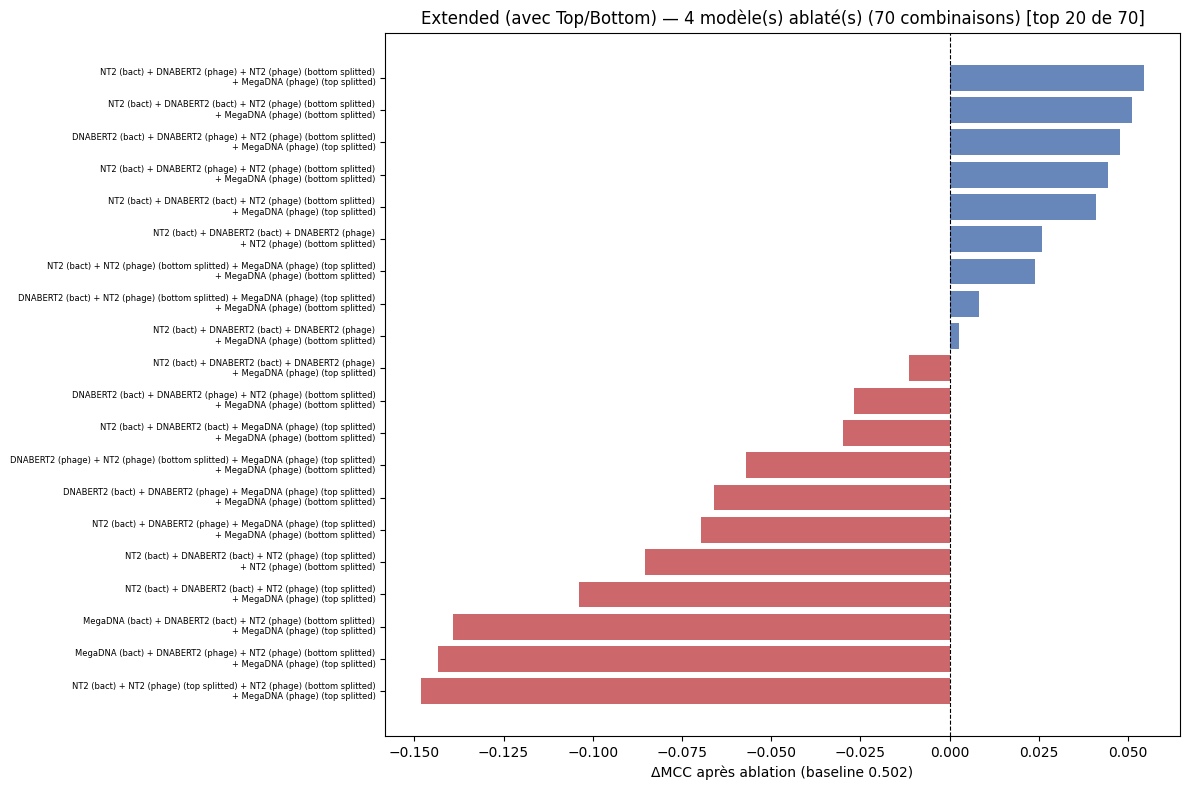

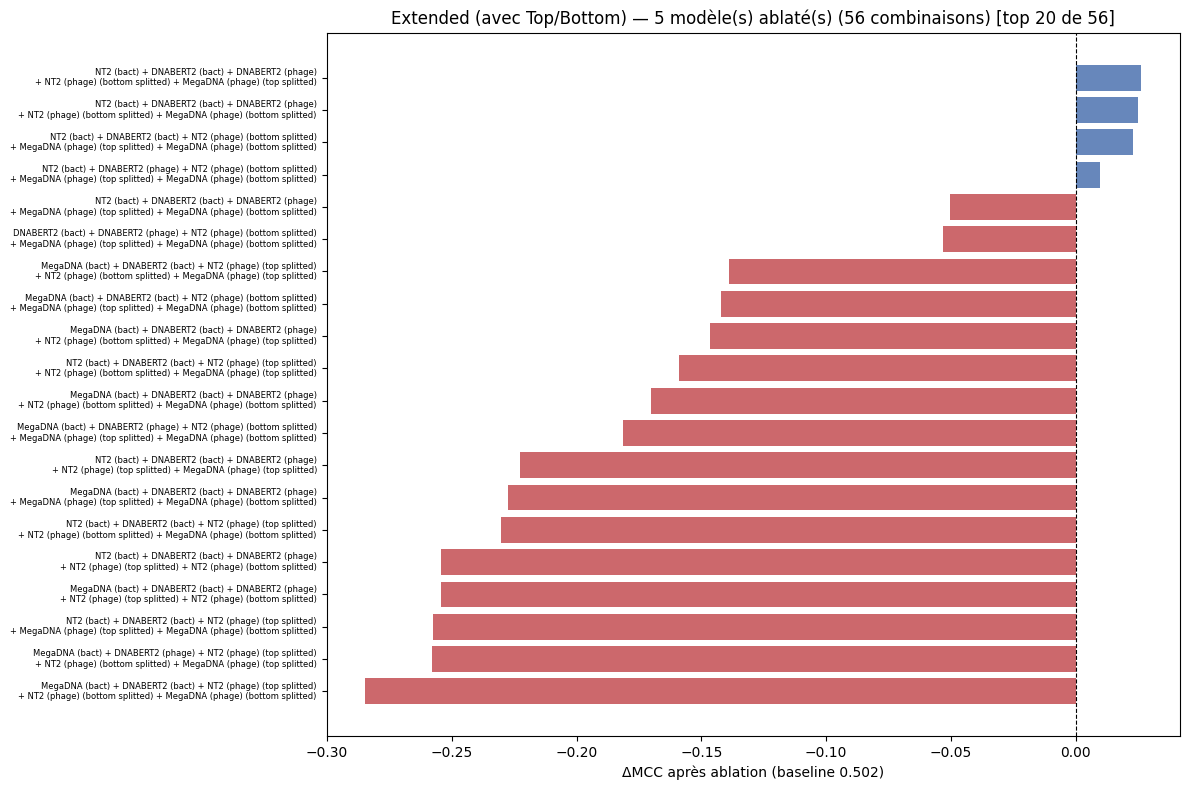

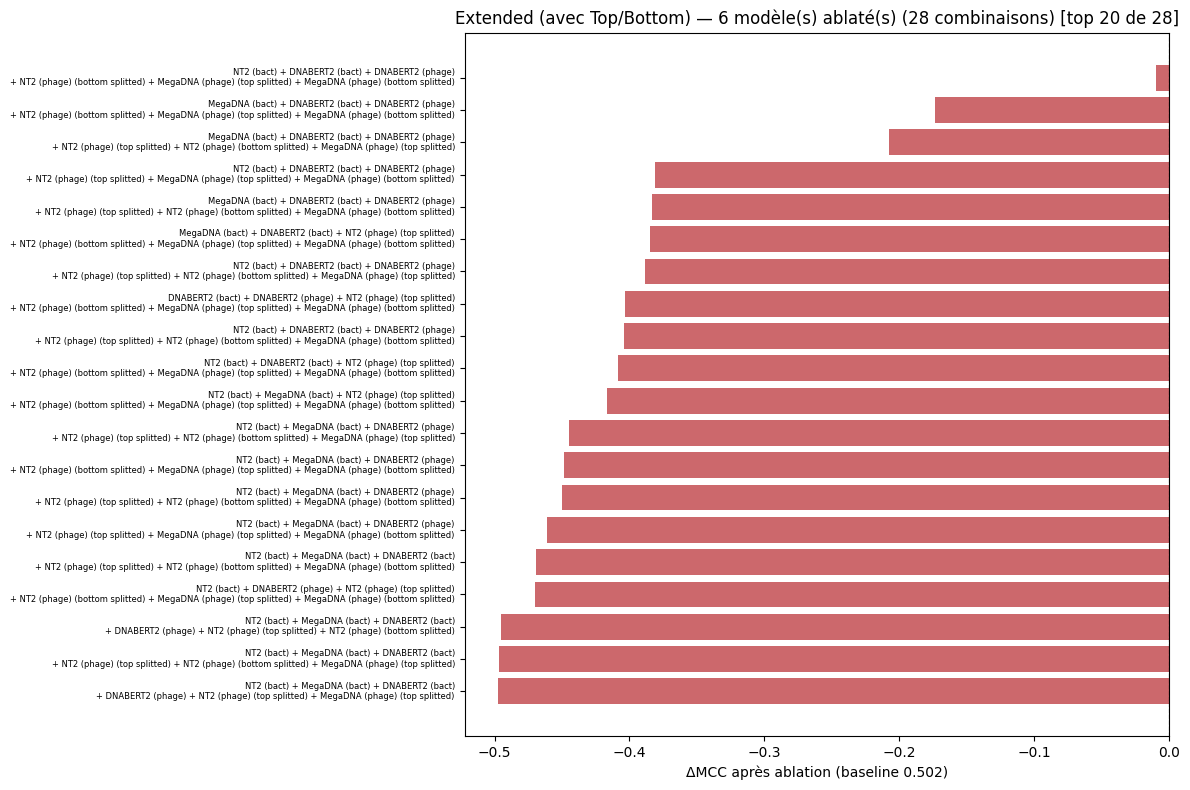

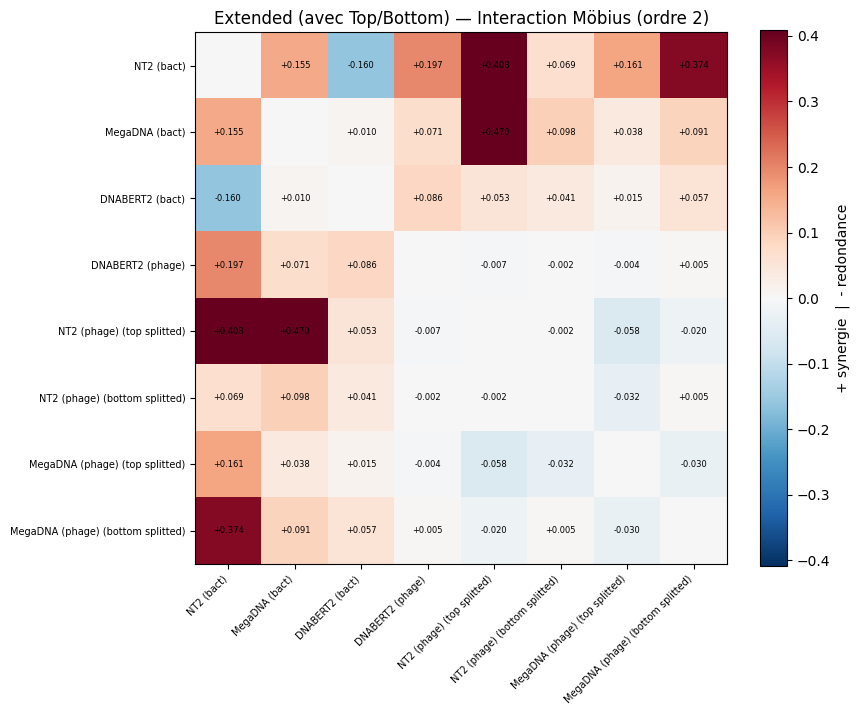

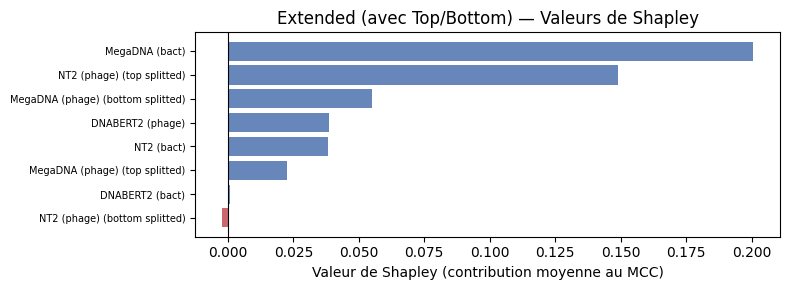

In [89]:
# Coalitions / interactions de Shapley via shapiq.
# Convention standard: v(S) = MCC quand seuls les modèles de S sont conservés
# (les autres dimensions sont mises à zéro). Avec cette convention:
#   Shapley phi_i > 0    -> le modèle i contribue positivement au MCC
#   Möbius I(i,j) > 0    -> synergie (complémentaires)
#   Möbius I(i,j) < 0    -> redondance
import shapiq
from itertools import combinations

MAX_K = 6

def make_game(infos):
    """Renvoie une fonction shapiq: (M, N) bool -> (M,) floats."""
    N = len(infos)
    def game_fun(coalitions: np.ndarray) -> np.ndarray:
        out = np.empty(len(coalitions), dtype=float)
        for k, coal in enumerate(coalitions):
            to_zero = [infos[i] for i in range(N) if not coal[i]]
            out[k] = run_median_embeddings(dataset, to_zero)
        return out
    return game_fun

configs = [
    ('Modèles entiers', list(bact_info.values()) + list(phage_info.values())),
    ('Extended (avec Top/Bottom)', [info for d in extended_infos for info in d.values()]),
]

results = {}
for title, infos in configs:
    N = len(infos)
    print(f'{title}: {N} joueurs -> {2**N} coalitions (exact)')
    game = make_game(infos)
    computer = shapiq.ExactComputer(game=game, n_players=N)
    sv      = computer(index='SV',      order=1)
    moebius = computer(index='Moebius', order=MAX_K)
    for i, info in enumerate(infos):
        info.result.setdefault('sv', {})[title] = float(sv[(i,)])
    results[title] = dict(infos=infos, game=game, moebius=moebius, sv=sv)

def plot_results(title, infos, game, moebius, sv):
    N = len(infos)
    short = [info.name() for info in infos]

    for size in range(1, MAX_K + 1):
        all_ablated = list(combinations(range(N), size))
        coals = np.ones((len(all_ablated), N), dtype=bool)
        for r, S in enumerate(all_ablated):
            coals[r, list(S)] = False
        deltas = game(coals) - baseline_mcc
        total_combos = len(all_ablated)

        # Cap : ne garder que les K combos les plus extrêmes par |ΔMCC|
        MAX_COMBOS = 20
        if total_combos > MAX_COMBOS:
            top_idx     = np.argsort(np.abs(deltas))[:MAX_COMBOS]
            deltas      = deltas[top_idx]
            all_ablated = [all_ablated[j] for j in top_idx]

        order = np.argsort(deltas)
        # Wrap labels: max 3 modèles par ligne
        def _wrap(combo, per_line=3):
            names  = [short[j] for j in combo]
            chunks = [' + '.join(names[k:k+per_line]) for k in range(0, len(names), per_line)]
            return '\n+ '.join(chunks)
        lbls = [_wrap(all_ablated[o]) for o in order]
        vs   = deltas[order]

        # Hauteur constante par barre, indépendante du wrapping des labels
        BAR_H = 0.4
        fig, ax = plt.subplots(figsize=(12, max(3, len(all_ablated) * BAR_H)))
        ax.barh(range(len(all_ablated)), vs,
                color=['#c44e52' if v < 0 else '#4c72b0' for v in vs], alpha=0.85)
        ax.axvline(0, color='black', ls='--', lw=0.8)
        ax.set_yticks(range(len(all_ablated)))
        ax.set_yticklabels(lbls, fontsize=6, va='center')
        ax.set_xlabel(f'ΔMCC après ablation (baseline {baseline_mcc:.3f})')
        trunc_note = f' [top {MAX_COMBOS} de {total_combos}]' if total_combos > MAX_COMBOS else ''
        ax.set_title(f'{title} — {size} modèle(s) ablaté(s) ({total_combos} combinaisons){trunc_note}')
        plt.tight_layout(); plt.show()



    I2 = np.zeros((N, N))
    for i, j in combinations(range(N), 2):
        I2[i, j] = I2[j, i] = moebius[(i, j)]
    fig, ax = plt.subplots(figsize=(max(6, N * 1.1), max(5, N * 0.9)))
    off_diag = np.abs(I2[np.triu_indices(N, k=1)])
    vmax = (np.sort(off_diag)[-2] if len(off_diag) >= 2 else off_diag.max()) or 1
    im = ax.imshow(I2, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(N)); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(N)); ax.set_yticklabels(short, fontsize=7)
    for i in range(N):
        for j in range(N):
            if i != j:
                ax.text(j, i, f'{I2[i,j]:+.3f}', ha='center', va='center', fontsize=6)
    plt.colorbar(im, ax=ax, label='+ synergie  |  - redondance')
    ax.set_title(f'{title} — Interaction Möbius (ordre 2)')
    plt.tight_layout(); plt.show()

    phi = np.array([sv[(i,)] for i in range(N)])
    order = np.argsort(phi)
    fig, ax = plt.subplots(figsize=(8, max(3, N * 0.35)))
    ax.barh(range(N), phi[order],
            color=['#c44e52' if p < 0 else '#4c72b0' for p in phi[order]], alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_yticks(range(N))
    ax.set_yticklabels([short[i] for i in order], fontsize=7)
    ax.set_xlabel('Valeur de Shapley (contribution moyenne au MCC)')
    ax.set_title(f'{title} — Valeurs de Shapley')
    plt.tight_layout(); plt.show()


for title, res in results.items():
    plot_results(title, **res)


In [90]:
to_remove  = [bact_info['DNABERT2-BottomTruncateStrategy-ov0-maxlen16384']]
to_remove += [bact_info['NT2-TruncateStrategy-250M-ov0']]

to_remove += [phage_info['DNABERT2-TKPert-concat-J16-g20-ov0-maxlen16384']]
to_remove += [phage_info['MegaDNA-TopBottomTruncateStrategy-concat-ov0']]
to_remove += [topbottom_phage_info['NT2-TopBottomTruncateStrategy-250M-ov0_bottom']]


print('Supprime:', [info.name() for info in to_remove])

mcc_reduced = run_median_embeddings(dataset, to_remove)
print(f'MCC baseline      : {baseline_mcc:.4f}')
print(f'MCC modèle réduit : {mcc_reduced:.4f}')
print(f'ΔMCC              : {mcc_reduced - baseline_mcc:+.4f}')


Supprime: ['DNABERT2 (bact)', 'NT2 (bact)', 'DNABERT2 (phage)', 'MegaDNA (phage)', 'NT2 (phage) (bottom splitted)']
MCC baseline      : 0.5022
MCC modèle réduit : 0.4924
ΔMCC              : -0.0098


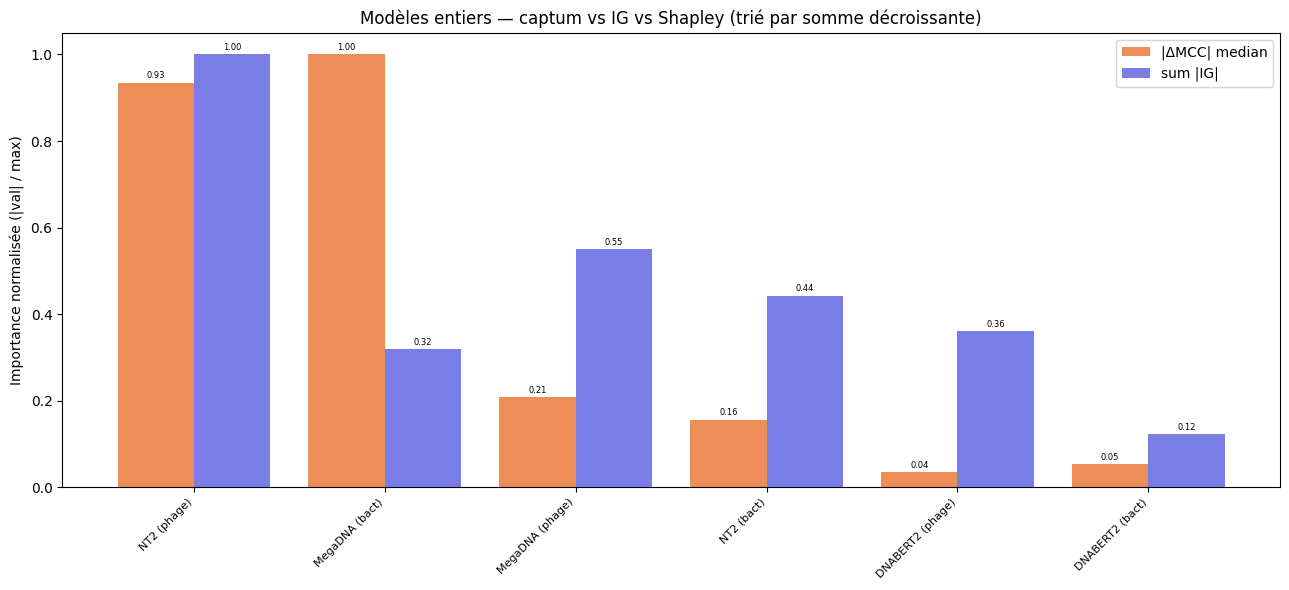

Modèles entiers — Classement par somme normalisée :
  NT2 (phage)                               score=1.935
  MegaDNA (bact)                            score=1.320
  MegaDNA (phage)                           score=0.758
  NT2 (bact)                                score=0.599
  DNABERT2 (phage)                          score=0.396
  DNABERT2 (bact)                           score=0.176


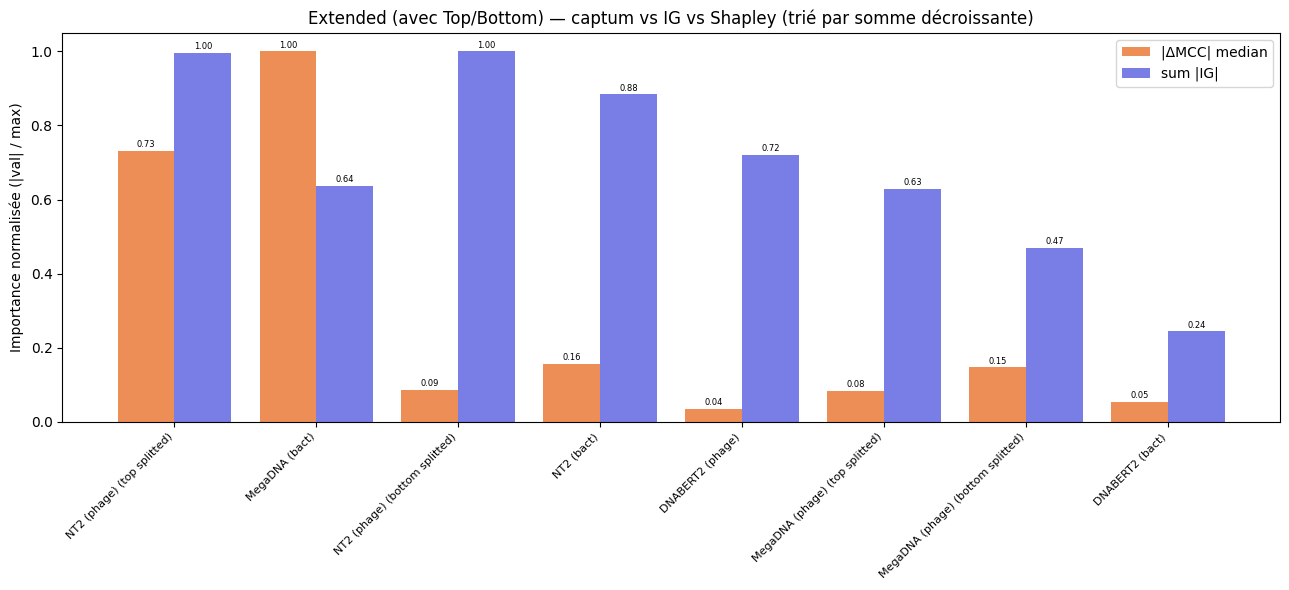

Extended (avec Top/Bottom) — Classement par somme normalisée :
  NT2 (phage) (top splitted)                score=1.727
  MegaDNA (bact)                            score=1.638
  NT2 (phage) (bottom splitted)             score=1.086
  NT2 (bact)                                score=1.040
  DNABERT2 (phage)                          score=0.755
  MegaDNA (phage) (top splitted)            score=0.712
  MegaDNA (phage) (bottom splitted)         score=0.617
  DNABERT2 (bact)                           score=0.298


In [ ]:
def normalize(arr):
    """Min-max vers [0, 1]."""
    arr = np.abs(np.array(arr, dtype=float))
    return (arr) / (arr.max() + 1e-10)


def plot_importance_comparison(all_entries, title):
    labels = [info.name() for info in all_entries]

    series_raw = {
        '|ΔMCC| median':    ([info.result['ablation']['median']['dmcc']     for info in all_entries], "#EB7A39"),
        'sum |IG|':       ([info.slice_sides(mean_ig_bact, mean_ig_phage).sum() for info in all_entries], "#6068E2"),
    }
    series_norm = {lbl: (normalize(vals), color) for lbl, (vals, color) in series_raw.items()}

    score = sum(vals for vals, _ in series_norm.values())
    order = np.argsort(score)[::-1]
    labels_s = [labels[i] for i in order]

    n_series = len(series_norm)
    x        = np.arange(len(all_entries))
    width    = 0.8 / n_series
    offsets  = (np.arange(n_series) - (n_series - 1) / 2) * width

    fig, ax = plt.subplots(figsize=(13, 6))
    for (lbl, (vals, color)), off in zip(series_norm.items(), offsets):
        vals_s = vals[order]
        ax.bar(x + off, vals_s, width, label=lbl, color=color, alpha=0.85)
        for i, v in enumerate(vals_s):
            ax.text(i + off, v + 0.01, f'{v:.2f}', ha='center', fontsize=6)
    ax.set_xticks(x); ax.set_xticklabels(labels_s, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Importance normalisée (|val| / max)')
    ax.set_title(f'{title} — captum vs IG vs Shapley (trié par somme décroissante)')
    ax.legend()
    plt.tight_layout(); plt.show()

    print(f'{title} — Classement par somme normalisée :')
    for i in order:
        print(f'  {labels[i]:40s}  score={score[i]:.3f}')


configs = [
    ('Modèles entiers',            list(bact_info.values()) + list(phage_info.values())),
    ('Extended (avec Top/Bottom)', [info for d in extended_infos for info in d.values()]),
]
for title, entries in configs:
    plot_importance_comparison(entries, title)


NT2        max_seq_len =   12276 nt  (12.3 kb)
MegaDNA    max_seq_len =  131071 nt  (131.1 kb)
NT2 (phage) (phage):
  Longueur moyenne : 66.0 kb  (mediane 52.5 kb)
  Ratio moyen      : 5.38x  max_len (12.3 kb)
  Sequences entières dans 1 chunk : 51/3449 (1.5%)
MegaDNA (phage) (phage):
  Longueur moyenne : 66.0 kb  (mediane 52.5 kb)
  Ratio moyen      : 0.50x  max_len (131.1 kb)
  Sequences entières dans 1 chunk : 3089/3449 (89.6%)


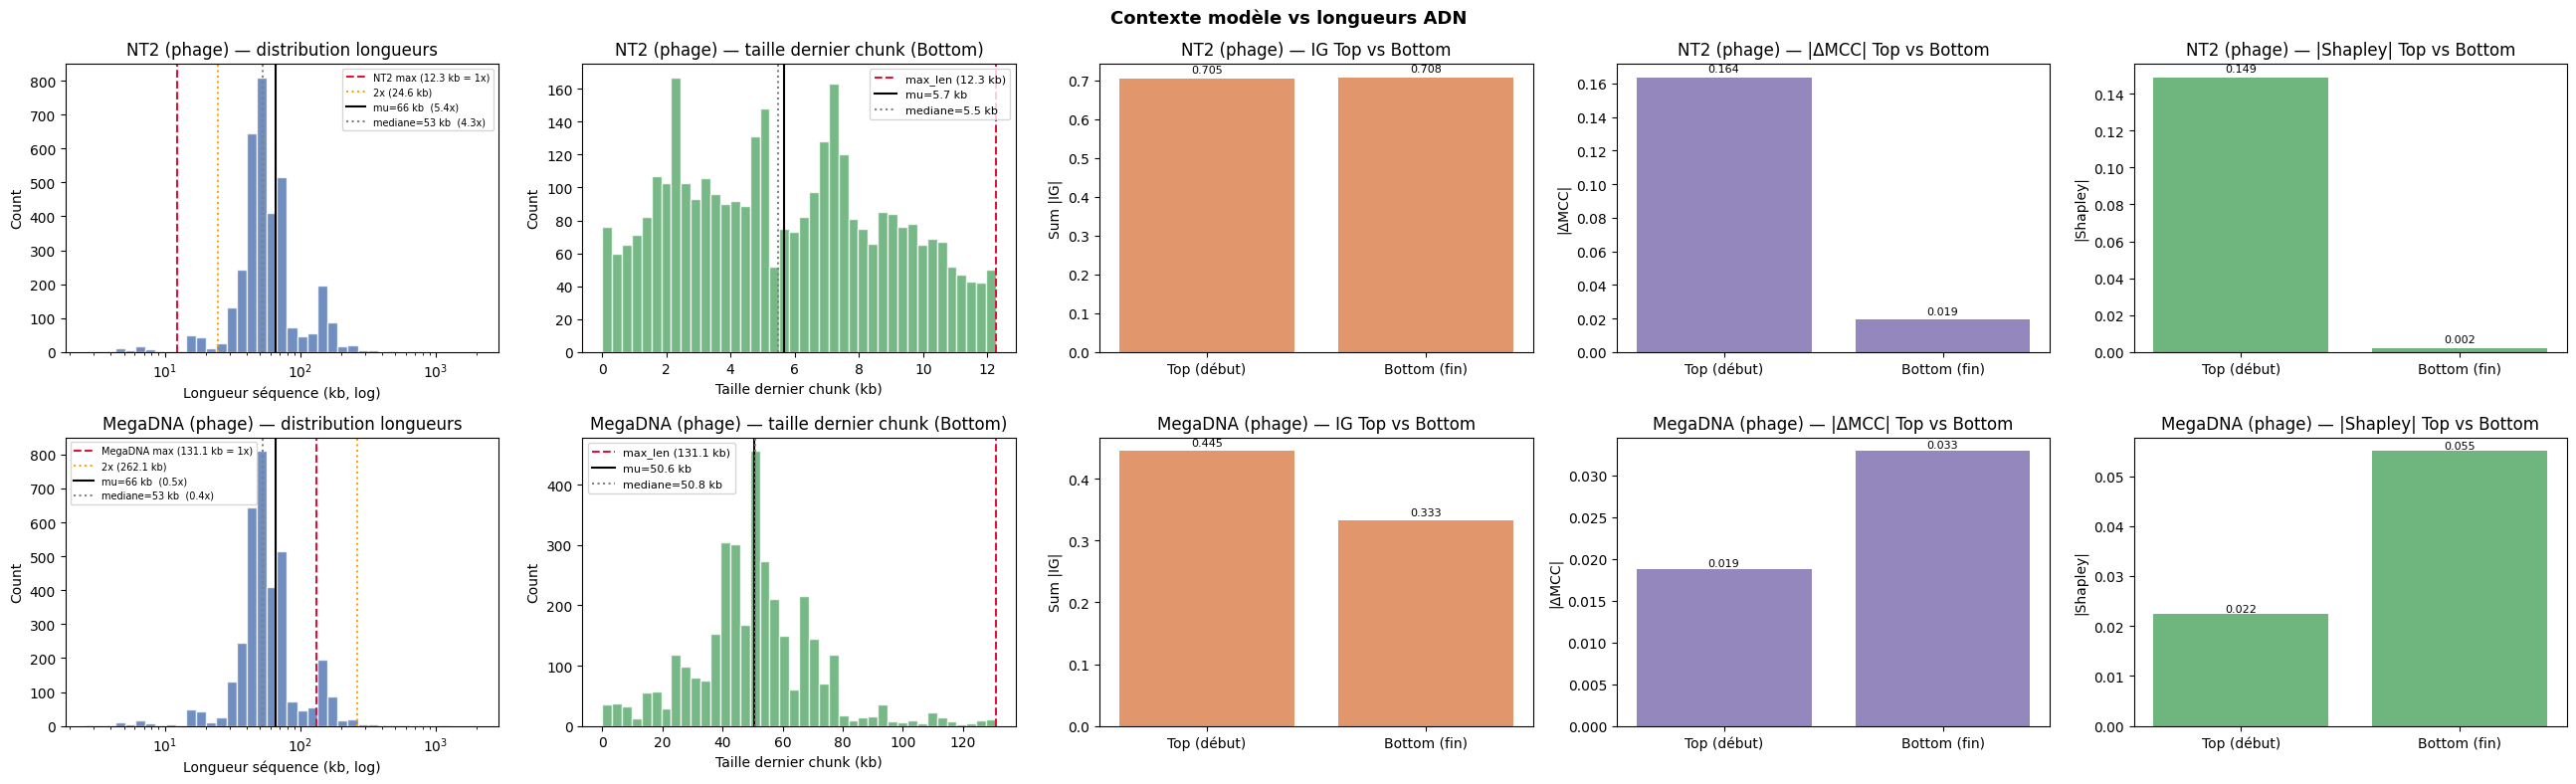

In [95]:
# ── Contexte modèles TopBottom vs tailles des séquences ADN ──────────────────


def last_chunk_size(seq_len, max_len):
    remainder = seq_len % max_len
    return remainder if remainder > 0 else max_len


def compute_context_stats(df, max_len, label, side):
    """Enrich df with coverage stats and print a summary."""
    df = df.copy()
    df['ratio']           = df['sequence_length'] / max_len
    df['n_chunks']        = df['sequence_length'].apply(lambda l: max(1, -(-l // max_len)))
    df['last_chunk_size'] = df['sequence_length'].apply(lambda l: last_chunk_size(l, max_len))

    seqs_in_ctx = int((df['sequence_length'] <= max_len).sum())
    print(f'{label} ({side.name}):')
    print(f'  Longueur moyenne : {df["sequence_length"].mean()/1000:.1f} kb  (mediane {df["sequence_length"].median()/1000:.1f} kb)')
    print(f'  Ratio moyen      : {df["ratio"].mean():.2f}x  max_len ({max_len/1000:.1f} kb)')
    print(f"  Sequences entières dans 1 chunk : {seqs_in_ctx}/{len(df)} ({100*seqs_in_ctx/len(df):.1f}%)")
    return df


# max_seq_len n'est set sur le modèle que si load_model=True.
# Les modèles ici sont instanciés avec load_model=False (embeddings lus du cache),
# donc on fallback sur des constantes connues par classe.
_MAX_LEN_FALLBACK = {'NT2': (2048 - 2) * 6, 'MegaDNA': 128 * 64 * 16 - 1}

def model_max_len(model):
    return getattr(model, 'max_seq_len', None) or _MAX_LEN_FALLBACK[type(model).__name__]


# Liste plate des modèles TopBottom (un par (modèle, côté))
tb_infos = [
    info
    for info_dict in base_infos
    for info in info_dict.values()
    if isinstance(info.model.merging_strategy, TopBottomTruncateStrategy)
]

# Affichage max_seq_len une fois par classe de modèle
printed = set()
for info in tb_infos:
    cls = type(info.model).__name__
    if cls in printed:
        continue
    printed.add(cls)
    max_len = model_max_len(info.model)
    print(f'{cls:10s} max_seq_len = {max_len:7d} nt  ({max_len/1000:.1f} kb)')

# Enrichissement des dataframes avec stats de couverture
enriched = {
    info.name(): compute_context_stats(info.side.get_df(), model_max_len(info.model), info.name(), info.side)
    for info in tb_infos
}

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(tb_infos), 5, figsize=(26, 4 * len(tb_infos)))

for row, info in enumerate(tb_infos):
    label      = info.name()
    model_name = type(info.model).__name__
    max_len    = model_max_len(info.model)
    side       = info.side
    df         = enriched[label]
    lengths_kb = df['sequence_length'] / 1000

    # Col 0 — longueur vs contexte (log + ratio)
    ax = axes[row, 0]
    log_bins = np.logspace(np.log10(lengths_kb.min()), np.log10(lengths_kb.max()), 40)
    ax.hist(lengths_kb, bins=log_bins, color='#4C72B0', alpha=0.8, edgecolor='white')
    for val, color, ls, lbl in [
        (max_len / 1000,      'crimson', '--', f'{model_name} max ({max_len/1000:.1f} kb = 1x)'),
        (2 * max_len / 1000,  'orange',  ':',  f'2x ({2*max_len/1000:.1f} kb)'),
        (lengths_kb.mean(),   'black',   '-',  f'mu={lengths_kb.mean():.0f} kb  ({lengths_kb.mean()*1000/max_len:.1f}x)'),
        (lengths_kb.median(), 'grey',    ':',  f'mediane={lengths_kb.median():.0f} kb  ({lengths_kb.median()*1000/max_len:.1f}x)'),
    ]:
        ax.axvline(val, color=color, linewidth=1.5, linestyle=ls, label=lbl)
    ax.set_xscale('log')
    ax.set_xlabel('Longueur séquence (kb, log)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} — distribution longueurs')
    ax.legend(fontsize=7)

    # Col 1 — dernier chunk
    ax = axes[row, 1]
    last_kb = df['last_chunk_size'] / 1000
    ax.hist(last_kb, bins=40, color='#55A868', alpha=0.8, edgecolor='white')
    for val, color, ls, lbl in [
        (max_len / 1000,   'crimson', '--', f'max_len ({max_len/1000:.1f} kb)'),
        (last_kb.mean(),   'black',   '-',  f'mu={last_kb.mean():.1f} kb'),
        (last_kb.median(), 'grey',    ':',  f'mediane={last_kb.median():.1f} kb'),
    ]:
        ax.axvline(val, color=color, linewidth=1.5, linestyle=ls, label=lbl)
    ax.set_xlabel('Taille dernier chunk (kb)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} — taille dernier chunk (Bottom)')
    ax.legend(fontsize=8)

    # Col 2 & 3 — IG sum et |ΔMCC| top vs bottom
    tb_dict = topbottom_bact_info if info.side is Side.bact else topbottom_phage_info
    tb_top = next((v for v in tb_dict.values()
                   if v.parent is info and v.part is TopBottomModelInfo.Part.top), None)
    tb_bot = next((v for v in tb_dict.values()
                   if v.parent is info and v.part is TopBottomModelInfo.Part.bottom), None)

    if tb_top and tb_bot and tb_top.result.get('ablation') and tb_bot.result.get('ablation'):
        xticks = ['Top (début)', 'Bottom (fin)']

        ax = axes[row, 2]
        ig_vals = [tb_top.slice_sides(mean_ig_bact, mean_ig_phage).sum(),
                   tb_bot.slice_sides(mean_ig_bact, mean_ig_phage).sum()]
        ax.bar([0, 1], ig_vals, color='#DD8452', alpha=0.85)
        ax.set_xticks([0, 1]); ax.set_xticklabels(xticks)
        ax.set_ylabel('Sum |IG|'); ax.set_title(f'{label} — IG Top vs Bottom')
        for xi, v in enumerate(ig_vals):
            ax.text(xi, v + ig_vals[0] * 0.02, f'{v:.3f}', ha='center', fontsize=8)

        ax = axes[row, 3]
        dmcc_vals = [abs(tb_top.result['ablation']['median']['dmcc']), abs(tb_bot.result['ablation']['median']['dmcc'])]
        ax.bar([0, 1], dmcc_vals, color='#8172B2', alpha=0.85)
        ax.set_xticks([0, 1]); ax.set_xticklabels(xticks)
        ax.set_ylabel('|ΔMCC|'); ax.set_title(f'{label} — |ΔMCC| Top vs Bottom')
        for xi, v in enumerate(dmcc_vals):
            ax.text(xi, v + dmcc_vals[0] * 0.02, f'{v:.3f}', ha='center', fontsize=8)

        ax = axes[row, 4]
        sv_key  = 'Extended (avec Top/Bottom)'
        sv_vals = [abs(tb_top.result['sv'].get(sv_key, 0.0)),
                   abs(tb_bot.result['sv'].get(sv_key, 0.0))]
        ax.bar([0, 1], sv_vals, color='#55A868', alpha=0.85)
        ax.set_xticks([0, 1]); ax.set_xticklabels(xticks)
        ax.set_ylabel('|Shapley|'); ax.set_title(f'{label} — |Shapley| Top vs Bottom')
        for xi, v in enumerate(sv_vals):
            ax.text(xi, v + (sv_vals[0] or 1) * 0.02, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Contexte modèle vs longueurs ADN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

NT2 (phage):
  cosine sim  : μ=0.852  σ=0.117  min=0.436  max=1.000
  corr/dim    : μ=0.369  (>0 = redondant, <0 = anti-corrélé)

MegaDNA (phage):
  cosine sim  : μ=0.921  σ=0.189  min=0.301  max=1.000
  corr/dim    : μ=0.615  (>0 = redondant, <0 = anti-corrélé)



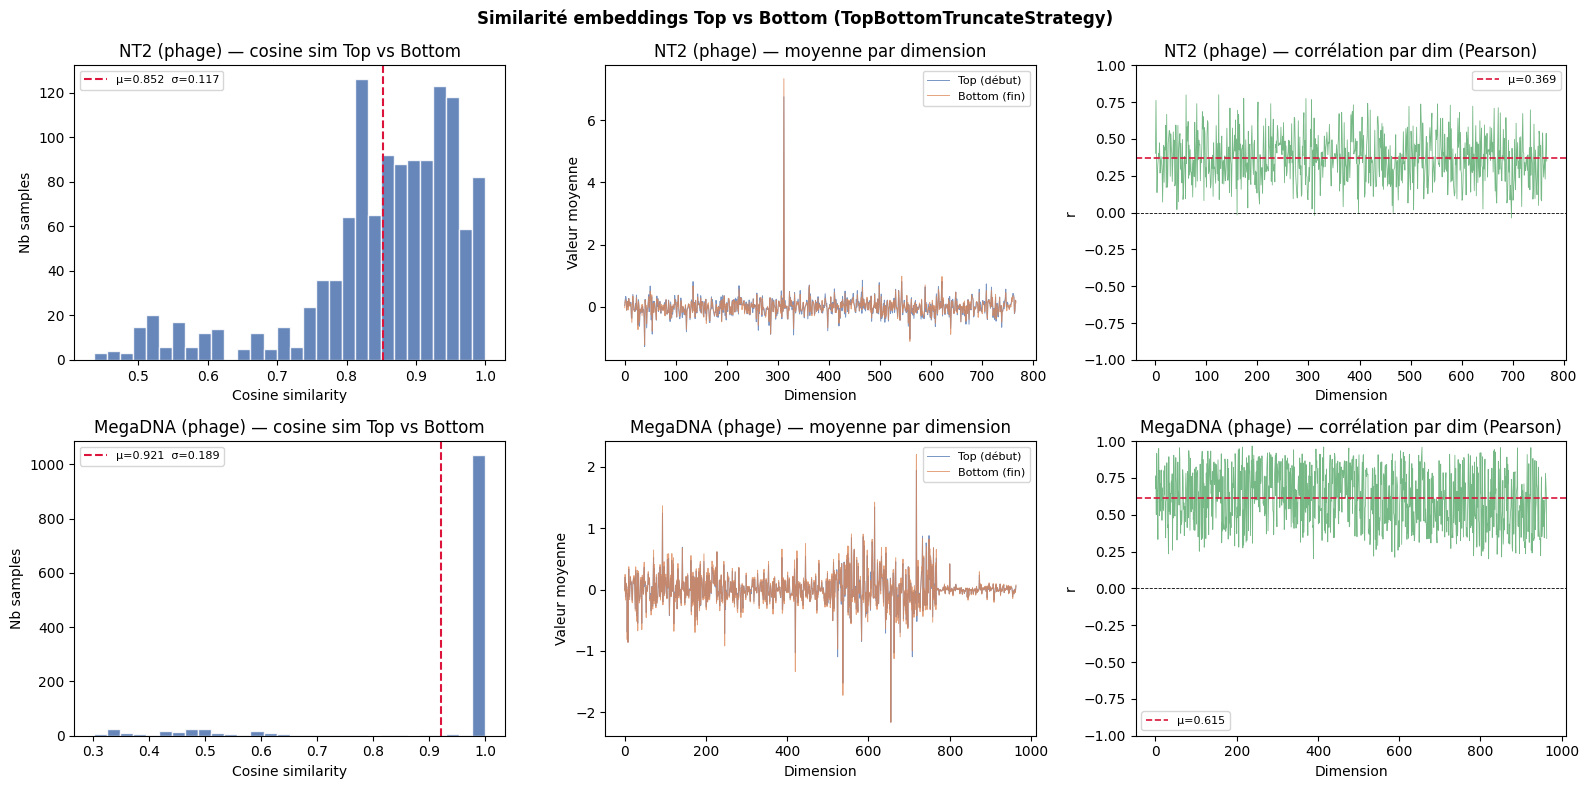

In [93]:
# ── Similarité Top vs Bottom des embeddings TopBottom ─────────────────────────
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim

Part = TopBottomModelInfo.Part

# Regrouper par paires top/bottom
pairs: dict = {}
for info in list(topbottom_bact_info.values()) + list(topbottom_phage_info.values()):
    pairs.setdefault(info.parent.name(), {})[info.part] = info

fig, axes = plt.subplots(len(pairs), 3, figsize=(16, 4 * len(pairs)), squeeze=False)

for row_idx, (base_name, parts) in enumerate(pairs.items()):
    top_info = parts[Part.top]
    bot_info = parts[Part.bottom]
    col      = top_info.embedding_col

    top_vecs = np.stack([row[col][top_info.slice].cpu().numpy() for _, row in dataset.iterrows()])
    bot_vecs = np.stack([row[col][bot_info.slice].cpu().numpy() for _, row in dataset.iterrows()])

    # Cosine similarity par sample
    sims = np.array([_cos_sim(t.reshape(1, -1), b.reshape(1, -1))[0, 0]
                     for t, b in zip(top_vecs, bot_vecs)])

    # Histogramme cosine similarity
    ax1 = axes[row_idx, 0]
    ax1.hist(sims, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax1.axvline(sims.mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'μ={sims.mean():.3f}  σ={sims.std():.3f}')
    ax1.set_title(f'{base_name} — cosine sim Top vs Bottom')
    ax1.set_xlabel('Cosine similarity'); ax1.set_ylabel('Nb samples')
    ax1.legend(fontsize=8)

    # Moyenne par dimension
    ax2 = axes[row_idx, 1]
    ax2.plot(top_vecs.mean(axis=0), alpha=0.75, linewidth=0.7,
             label='Top (début)', color='#4C72B0')
    ax2.plot(bot_vecs.mean(axis=0), alpha=0.75, linewidth=0.7,
             label='Bottom (fin)', color='#DD8452')
    ax2.set_title(f'{base_name} — moyenne par dimension')
    ax2.set_xlabel('Dimension'); ax2.set_ylabel('Valeur moyenne')
    ax2.legend(fontsize=8)

    # Corrélation par dimension (Pearson)
    corr_per_dim = np.array([np.corrcoef(top_vecs[:, d], bot_vecs[:, d])[0, 1]
                              for d in range(top_vecs.shape[1])])
    ax3 = axes[row_idx, 2]
    ax3.plot(corr_per_dim, linewidth=0.6, alpha=0.8, color='#55A868')
    ax3.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax3.axhline(corr_per_dim.mean(), color='crimson', linewidth=1.2, linestyle='--',
                label=f'μ={corr_per_dim.mean():.3f}')
    ax3.set_title(f'{base_name} — corrélation par dim (Pearson)')
    ax3.set_xlabel('Dimension'); ax3.set_ylabel('r')
    ax3.set_ylim(-1, 1); ax3.legend(fontsize=8)

    print(f'{base_name}:')
    print(f'  cosine sim  : μ={sims.mean():.3f}  σ={sims.std():.3f}  min={sims.min():.3f}  max={sims.max():.3f}')
    print(f'  corr/dim    : μ={corr_per_dim.mean():.3f}  (>0 = redondant, <0 = anti-corrélé)')
    print()

plt.suptitle('Similarité embeddings Top vs Bottom (TopBottomTruncateStrategy)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
